# Guida a Pandas, NumPy, SciPy e Matplotlib
## Analisi dei Dati con Python — Classe Quarta Istituto Tecnico

Questa guida introduce le principali librerie Python per l'analisi e la visualizzazione dei dati.
Gli esempi usano un dataset di voti scolastici per rendere tutto concreto e familiare.

| Libreria | Utilizzo principale |
|----------|---------------------|
| **Pandas** | Manipolazione di dati strutturati (tabelle) |
| **NumPy** | Calcolo numerico, array e matrici |
| **SciPy** | Funzioni scientifiche e statistiche avanzate |
| **Matplotlib** | Creazione di grafici e visualizzazioni |
| **Seaborn** | Grafici statistici con stile migliorato |

---

## Indice
1. [Setup e Importazione delle Librerie](#1)
2. [Pandas: Series e DataFrame — Differenze fondamentali](#2)
3. [Creazione di un DataFrame](#3)
4. [Caricamento di File CSV](#4)
5. [Selezione e Manipolazione di Righe e Colonne](#5)
6. [Tipi di Dati e Valori Mancanti](#6)
7. [Operazioni Statistiche sui Dati](#7)
8. [Creare DataFrame da DataFrame Esistenti](#8)
9. [Crosstab e Prodotti fra Serie](#9)
10. [Visualizzazione dei Dati con Grafici](#10)
11. [Heatmap](#11)
12. [Approfondimenti: NumPy e SciPy](#12)

---
## 1. Setup e Importazione delle Librerie <a id='1'></a>

Prima di tutto importiamo tutte le librerie che useremo in questa guida.
Il comando `%matplotlib inline` dice a Jupyter di mostrare i grafici direttamente nel notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
import io
import warnings

# Mostra i grafici nel notebook
%matplotlib inline

# Impostazioni grafici
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')

# Versioni delle librerie
print(f'pandas   : {pd.__version__}')
print(f'numpy    : {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/workspaces/data-analysis-4Ai-2026/.venv/lib/python3.12/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
            ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/workspaces/data-analysis-4Ai-2026/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/workspaces/data-analysis-4Ai-2026/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 347, in dispatch_control
    async with self._control_lock:
               ^^^^^^^^^^^^^^^^^^
  File "/workspaces/data-analysis-4Ai-2026/.venv/lib/python3.12/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
                   

pandas   : 3.0.1
numpy    : 2.4.3
matplotlib: 3.10.8


---
## 2. Pandas: Series e DataFrame — Differenze fondamentali <a id='2'></a>

Pandas si basa su due strutture dati fondamentali:

### Series — una colonna
Una **Series** è una sequenza **monodimensionale** di valori con un indice associato.
Pensala come una singola colonna di una tabella Excel, oppure come una lista Python ma con etichette (indici).

```
0    Alice
1    Bruno
2    Carla
dtype: object
```

### DataFrame — una tabella
Un **DataFrame** è una struttura **bidimensionale** (righe × colonne), simile a una tabella Excel o a un database.
Ogni colonna di un DataFrame è una Series.

```
    nome  voto
0   Alice     8
1   Bruno     6
2   Carla     9
```

**In sintesi:** `DataFrame = dizionario di Series`

In [2]:
# --- SERIES ---

# Creare una Series da una lista
voti = pd.Series([8, 6, 9, 7, 8, 5])
print('Series di voti:')
print(voti)
print()

# Series con indice personalizzato (etichette invece di numeri)
voti_nominali = pd.Series(
    [8, 6, 9, 7, 8],
    index=['Alice', 'Bruno', 'Carla', 'Davide', 'Elena']
)
print('Series con indice nominale:')
print(voti_nominali)

Series di voti:
0    8
1    6
2    9
3    7
4    8
5    5
dtype: int64

Series con indice nominale:
Alice     8
Bruno     6
Carla     9
Davide    7
Elena     8
dtype: int64


### Proprietà e metodi di una Series

Una volta creata una Series è possibile accedere alle sue caratteristiche tramite **proprietà** (senza parentesi) e **metodi** (con parentesi):

| Proprietà / Metodo | Descrizione |
|--------------------|-------------|
| `.values` | Array NumPy con i valori della Series |
| `.index` | L'indice (etichette) della Series |
| `.dtype` | Tipo di dato (`int64`, `float64`, `object`...) |
| `len(s)` | Numero di elementi |
| `s['etichetta']` | Accesso a un elemento tramite la sua etichetta |
| `s + n`, `s * n` | Operazione applicata a ogni elemento |
| `s > n` | Confronto: restituisce una Series di `True`/`False` |

Le operazioni su una Series si applicano **elemento per elemento** senza cicli `for`: questo meccanismo si chiama _vectorization_ ed è il cuore di pandas e NumPy.


In [3]:
# Proprietà di una Series
print('Valori:', voti_nominali.values)       # array numpy con i valori
print('Indice:', list(voti_nominali.index))  # lista degli indici
print('Tipo:  ', voti_nominali.dtype)        # tipo di dato
print('Lungh.:', len(voti_nominali))         # numero di elementi
print()

# Accesso agli elementi
print('Voto di Alice:', voti_nominali['Alice'])
print('Voto di Carla:', voti_nominali['Carla'])
print()

# Operazioni su tutta la Series (si applicano elemento per elemento)
print('Voti + 1:')
print(voti_nominali + 1)
print()
print('Voti > 7:')
print(voti_nominali > 7)

Valori: [8 6 9 7 8]
Indice: ['Alice', 'Bruno', 'Carla', 'Davide', 'Elena']
Tipo:   int64
Lungh.: 5

Voto di Alice: 8
Voto di Carla: 9

Voti + 1:
Alice      9
Bruno      7
Carla     10
Davide     8
Elena      9
dtype: int64

Voti > 7:
Alice      True
Bruno     False
Carla      True
Davide    False
Elena      True
dtype: bool


---
## 3. Creazione di un DataFrame <a id='3'></a>

Esistono diversi modi per creare un DataFrame. I più comuni sono:
- Da un **dizionario** Python (chiave = nome colonna, valore = lista di dati)
- Da una **lista di liste** o lista di dizionari
- Da un **array NumPy**
- Caricando un **file CSV** (vedremo nella sezione 4)

In [4]:
# Metodo 1: da dizionario (il più comune)
# Ogni chiave diventa il nome della colonna,
# ogni lista contiene i valori di quella colonna

dati = {
    'nome':        ['Alice', 'Bruno', 'Carla', 'Davide', 'Elena',
                    'Franco', 'Giulia', 'Hasan', 'Irene', 'Luca',
                    'Maria', 'Nicola'],
    'classe':      ['4A', '4A', '4B', '4B', '4A',
                    '4C', '4C', '4B', '4A', '4C',
                    '4B', '4C'],
    'sesso':       ['F', 'M', 'F', 'M', 'F',
                    'M', 'F', 'M', 'F', 'M',
                    'F', 'M'],
    'eta':         [17, 18, 17, 18, 17, 18, 17, 18, 17, 18, 17, 18],
    'matematica':  [8, 6, 9, 7, 8, 5, 9, 7, 6, 8, 7, 6],
    'italiano':    [7, 8, 6, 7, 9, 8, 7, 6, 8, 7, 8, 9],
    'informatica': [9, 7, 8, 9, 7, 6, 9, 8, 7, 9, 8, 7],
    'fisica':      [8, 6, 7, 8, 7, 5, 8, 7, 6, 7, 7, 6],
    'storia':      [7, 9, 8, 6, 8, 9, 7, 7, 9, 8, 7, 8]
}

df = pd.DataFrame(dati)

# Informazioni di base
print(f'Dimensioni: {df.shape[0]} righe x {df.shape[1]} colonne')
print(f'Colonne: {list(df.columns)}')
print()

# Mostra il DataFrame
df

Dimensioni: 12 righe x 9 colonne
Colonne: ['nome', 'classe', 'sesso', 'eta', 'matematica', 'italiano', 'informatica', 'fisica', 'storia']



,nome,classe,sesso,eta,matematica,italiano,informatica,fisica,storia
0,Alice,4A,F,17,8,7,9,8,7
1,Bruno,4A,M,18,6,8,7,6,9
2,Carla,4B,F,17,9,6,8,7,8
3,Davide,4B,M,18,7,7,9,8,6
4,Elena,4A,F,17,8,9,7,7,8
5,Franco,4C,M,18,5,8,6,5,9
6,Giulia,4C,F,17,9,7,9,8,7
7,Hasan,4B,M,18,7,6,8,7,7
8,Irene,4A,F,17,6,8,7,6,9
9,Luca,4C,M,18,8,7,9,7,8


### Metodo 2 — Lista di dizionari

Un formato alternativo molto leggibile: si passa una **lista di dizionari** dove ogni dizionario rappresenta **una riga**. Le chiavi diventano automaticamente i nomi delle colonne.

```python
pd.DataFrame([
    {'col1': val1, 'col2': val2},  # riga 0
    {'col1': val3, 'col2': val4},  # riga 1
])
```

È utile quando i dati vengono costruiti iterativamente (es. in un ciclo `for` o ricevuti da un'API REST in formato JSON).


In [5]:
# Metodo 2: da lista di dizionari
# Ogni dizionario rappresenta una riga
righe = [
    {'prodotto': 'Penna',   'prezzo': 1.20, 'quantita': 100},
    {'prodotto': 'Quaderno','prezzo': 2.50, 'quantita': 50},
    {'prodotto': 'Zaino',   'prezzo': 35.0, 'quantita': 15},
    {'prodotto': 'Regolo',  'prezzo': 0.80, 'quantita': 200},
]

df_prodotti = pd.DataFrame(righe)
print('DataFrame da lista di dizionari:')
df_prodotti

DataFrame da lista di dizionari:


,prodotto,prezzo,quantita
0,Penna,1.2,100
1,Quaderno,2.5,50
2,Zaino,35.0,15
3,Regolo,0.8,200


### Metodo 3 — Array NumPy

Quando i dati provengono da calcoli numerici (es. simulazioni o operazioni matriciali), si può passare direttamente un **array NumPy 2D** a `pd.DataFrame()`.

In questo caso è obbligatorio specificare i nomi delle colonne con il parametro `columns=[...]`, altrimenti pandas userebbe interi (0, 1, 2...) come nomi.

```python
pd.DataFrame(array_2d, columns=['nome_col1', 'nome_col2', ...])
```


In [6]:
# Metodo 3: da array NumPy
# Utile quando i dati provengono da calcoli numerici
matrice = np.array([
    [1, 100, 3.5],
    [2, 200, 7.0],
    [3, 300, 10.5]
])

df_numpy = pd.DataFrame(matrice, columns=['id', 'valore', 'punteggio'])
print('DataFrame da array NumPy:')
df_numpy

DataFrame da array NumPy:


,id,valore,punteggio
0,1.0,100.0,3.5
1,2.0,200.0,7.0
2,3.0,300.0,10.5


### Esplorare un DataFrame: .head(), .tail(), .shape

Appena creato o caricato un DataFrame, i primi comandi da eseguire sono:

| Metodo / Proprietà | Descrizione |
|---------------------|-------------|
| `df.head(n)` | Mostra le prime `n` righe (default: 5) |
| `df.tail(n)` | Mostra le ultime `n` righe (default: 5) |
| `df.shape` | Tupla `(n_righe, n_colonne)` — è una **proprietà**, non un metodo |
| `df.columns` | Nomi delle colonne come indice pandas |

> **Consiglio:** esegui sempre `.head()` subito dopo aver caricato i dati per controllare che siano stati letti correttamente.


In [7]:
# Esploriamo il nostro dataset principale

print('--- Prime 5 righe (.head()) ---')
print(df.head())
print()

print('--- Ultime 3 righe (.tail(3)) ---')
print(df.tail(3))
print()

print('--- Dimensioni: (righe, colonne) ---')
print(df.shape)

--- Prime 5 righe (.head()) ---
     nome classe sesso  eta  matematica  italiano  informatica  fisica  storia
0   Alice     4A     F   17           8         7            9       8       7
1   Bruno     4A     M   18           6         8            7       6       9
2   Carla     4B     F   17           9         6            8       7       8
3  Davide     4B     M   18           7         7            9       8       6
4   Elena     4A     F   17           8         9            7       7       8

--- Ultime 3 righe (.tail(3)) ---
      nome classe sesso  eta  matematica  italiano  informatica  fisica  \
9     Luca     4C     M   18           8         7            9       7   
10   Maria     4B     F   17           7         8            8       7   
11  Nicola     4C     M   18           6         9            7       6   

    storia  
9        8  
10       7  
11       8  

--- Dimensioni: (righe, colonne) ---
(12, 9)


### Riepilogo strutturale: .info()

`.info()` stampa un **riepilogo tecnico** del DataFrame:
- Il numero totale di righe
- Per ogni colonna: nome, quanti valori sono **non-null** e tipo di dato
- La memoria totale occupata

È il modo più rapido per individuare **colonne con valori mancanti** (quando `Non-Null Count` è inferiore al totale delle righe) e **tipi di dato errati** (es. una colonna numerica letta come `object`).


In [8]:
# .info() mostra: colonne, tipo di dato, valori non nulli
print('--- Informazioni sul DataFrame (.info()) ---')
df.info()

--- Informazioni sul DataFrame (.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   nome         12 non-null     str  
 1   classe       12 non-null     str  
 2   sesso        12 non-null     str  
 3   eta          12 non-null     int64
 4   matematica   12 non-null     int64
 5   italiano     12 non-null     int64
 6   informatica  12 non-null     int64
 7   fisica       12 non-null     int64
 8   storia       12 non-null     int64
dtypes: int64(6), str(3)
memory usage: 996.0 bytes


### Statistiche di base: .describe()

`.describe()` calcola automaticamente le principali statistiche per ogni colonna **numerica**:

| Campo | Significato |
|-------|-------------|
| `count` | Numero di valori non-null |
| `mean` | Media aritmetica |
| `std` | Deviazione standard |
| `min` / `max` | Valore minimo e massimo |
| `25%`, `50%`, `75%` | Quartili (il 50° è la mediana) |

Per includere anche le colonne testuali: `df.describe(include='all')`


In [9]:
# .describe() calcola automaticamente le statistiche di base
# per tutte le colonne numeriche
print('--- Statistiche descrittive (.describe()) ---')
df.describe()

--- Statistiche descrittive (.describe()) ---


,eta,matematica,italiano,informatica,fisica,storia
count,12.000000,12.000000,12.0,12.000000,12.000000,12.000000
mean,17.500000,7.166667,7.5,7.833333,6.833333,7.750000
std,0.522233,1.267304,1.0,1.029857,0.937437,0.965307
min,17.000000,5.000000,6.0,6.000000,5.000000,6.000000
25%,17.000000,6.000000,7.0,7.000000,6.000000,7.000000
50%,17.500000,7.000000,7.5,8.000000,7.000000,8.000000
75%,18.000000,8.000000,8.0,9.000000,7.250000,8.250000
max,18.000000,9.000000,9.0,9.000000,8.000000,9.000000


---
## 4. Caricamento di File CSV <a id='4'></a>

Il formato **CSV** (Comma-Separated Values) è uno dei formati più usati per scambiare dati.
Pandas lo legge con `pd.read_csv()` e lo scrive con `df.to_csv()`.

Parametri più utili di `read_csv`:
| Parametro | Descrizione | Esempio |
|-----------|-------------|--------|
| `sep` | Separatore dei campi | `sep=';'` |
| `header` | Riga dell'intestazione | `header=0` |
| `index_col` | Colonna da usare come indice | `index_col='nome'` |
| `usecols` | Solo alcune colonne | `usecols=['nome','voto']` |
| `nrows` | Quante righe leggere | `nrows=100` |
| `encoding` | Codifica del file | `encoding='utf-8'` |
| `na_values` | Valori da trattare come NaN | `na_values=['N/A', '-']` |

In [10]:
# Salviamo il nostro DataFrame come CSV
df.to_csv('studenti.csv', index=False, encoding='utf-8')
print('File studenti.csv salvato.')

# Verifichiamo il contenuto (prime righe del file)
with open('studenti.csv', 'r', encoding='utf-8') as f:
    for i, riga in enumerate(f):
        print(riga.rstrip())
        if i >= 4:
            print('...')
            break

File studenti.csv salvato.
nome,classe,sesso,eta,matematica,italiano,informatica,fisica,storia
Alice,4A,F,17,8,7,9,8,7
Bruno,4A,M,18,6,8,7,6,9
Carla,4B,F,17,9,6,8,7,8
Davide,4B,M,18,7,7,9,8,6
...


### Leggere un CSV: pd.read_csv()

`pd.read_csv(percorso)` carica il file e restituisce un DataFrame. Il percorso può essere relativo alla cartella di lavoro o assoluto.

Dopo il caricamento è buona abitudine verificare le dimensioni con `.shape` e controllare le prime righe con `.head()` per accertarsi che i dati siano stati letti correttamente (intestazioni, tipi, valori mancanti).


In [11]:
# Carichiamo il CSV
df_caricato = pd.read_csv('studenti.csv')

print(f'Righe: {len(df_caricato)}, Colonne: {len(df_caricato.columns)}')
df_caricato.head()

Righe: 12, Colonne: 9


,nome,classe,sesso,eta,matematica,italiano,informatica,fisica,storia
0,Alice,4A,F,17,8,7,9,8,7
1,Bruno,4A,M,18,6,8,7,6,9
2,Carla,4B,F,17,9,6,8,7,8
3,Davide,4B,M,18,7,7,9,8,6
4,Elena,4A,F,17,8,9,7,7,8


### Opzioni avanzate di read_csv: usecols e index_col

- **`usecols`**: lista delle colonne da caricare — evita di leggere dati inutili, risparmiando memoria e velocizzando il caricamento su file grandi.
- **`index_col`**: nome (o numero) della colonna da usare come **indice** del DataFrame invece del progressivo 0, 1, 2...

Usare `index_col` ha senso quando una colonna identifica univocamente ogni riga (es. un codice studente, un nome o un ID).


In [12]:
# Caricare solo alcune colonne
df_voti = pd.read_csv('studenti.csv', usecols=['nome', 'matematica', 'italiano', 'informatica'])
print('Solo colonne selezionate:')
print(df_voti.head())
print()

# Usare una colonna come indice
df_idx = pd.read_csv('studenti.csv', index_col='nome')
print('Con colonna nome come indice:')
print(df_idx.head(3))

Solo colonne selezionate:
     nome  matematica  italiano  informatica
0   Alice           8         7            9
1   Bruno           6         8            7
2   Carla           9         6            8
3  Davide           7         7            9
4   Elena           8         9            7

Con colonna nome come indice:
      classe sesso  eta  matematica  italiano  informatica  fisica  storia
nome                                                                      
Alice     4A     F   17           8         7            9       8       7
Bruno     4A     M   18           6         8            7       6       9
Carla     4B     F   17           9         6            8       7       8


### CSV con separatore diverso dalla virgola e io.StringIO

In Italia Excel salva i CSV con **punto e virgola** (`;`) come separatore perché la virgola è già usata come separatore decimale. In questi casi va specificato `sep=';'` (o `sep='\t'` per file TSV separati da tabulazione).

`io.StringIO(testo)` permette di trattare una **stringa Python** come se fosse un file aperto in lettura — molto comodo per test e dimostrazioni senza creare file su disco.


In [13]:
# Esempio: CSV con punto e virgola come separatore (comune in Italia)
# I file Excel italiani spesso usano ; invece di ,

csv_italiano = """nome;voto;materia
Alice;8;matematica
Bruno;6;matematica
Carla;9;matematica
"""

# Usiamo io.StringIO per leggere una stringa come se fosse un file
df_ita = pd.read_csv(io.StringIO(csv_italiano), sep=';')
print('CSV con separatore punto e virgola:')
df_ita

CSV con separatore punto e virgola:


,nome,voto,materia
0,Alice,8,matematica
1,Bruno,6,matematica
2,Carla,9,matematica


---
## 5. Selezione e Manipolazione di Righe e Colonne <a id='5'></a>

### Selezionare colonne
- `df['colonna']` → restituisce una **Series** (singola colonna)
- `df[['col1', 'col2']]` → restituisce un **DataFrame** (più colonne)

### Selezionare righe
- `df.loc[etichetta]` → selezione per **etichetta** (nome dell'indice)
- `df.iloc[numero]` → selezione per **posizione numerica** (0, 1, 2...)
- `df[condizione]` → **filtraggio** per condizione booleana

> **Regola mnemonica**: `loc` = **l**abel, `iloc` = **i**nteger

In [14]:
# Selezionare una singola colonna → Series
voti_mat = df['matematica']
print('Tipo:', type(voti_mat))
print(voti_mat)
print()

# Selezionare più colonne → DataFrame
voti_materie = df[['nome', 'matematica', 'italiano', 'informatica']]
print('Tipo:', type(voti_materie))
voti_materie

Tipo: <class 'pandas.Series'>
0     8
1     6
2     9
3     7
4     8
5     5
6     9
7     7
8     6
9     8
10    7
11    6
Name: matematica, dtype: int64

Tipo: <class 'pandas.DataFrame'>


,nome,matematica,italiano,informatica
0,Alice,8,7,9
1,Bruno,6,8,7
2,Carla,9,6,8
3,Davide,7,7,9
4,Elena,8,9,7
5,Franco,5,8,6
6,Giulia,9,7,9
7,Hasan,7,6,8
8,Irene,6,8,7
9,Luca,8,7,9


### Selezione per posizione: .iloc[]

`.iloc[]` (**I**nteger **LOC**ation) seleziona righe e colonne tramite la loro **posizione numerica**, come le liste Python (indice base 0):

```python
df.iloc[0]          # prima riga
df.iloc[-1]         # ultima riga
df.iloc[2:5]        # righe 2, 3, 4 (il 5 è escluso, come negli slice Python)
df.iloc[0:3, 0:4]   # righe 0-2 E colonne 0-3
```

> **Regola mnemonica:** `iloc` = **i**nteger → selezione per numero.


In [15]:
# .iloc — selezione per posizione numerica (come le liste Python)
print('Prima riga (iloc[0]):')
riga = df.iloc[0] 
print(type(riga))
print(riga)
print()

print('Righe 2, 3, 4 (iloc[2:5]):')
print(df.iloc[2:5])
print()

# .iloc con righe E colonne: iloc[righe, colonne]
print('Righe 0-2, colonne 0-3 (iloc[0:3, 0:4]):')
print(df.iloc[0:3, 0:4])

Prima riga (iloc[0]):
<class 'pandas.Series'>
nome           Alice
classe            4A
sesso              F
eta               17
matematica         8
italiano           7
informatica        9
fisica             8
storia             7
Name: 0, dtype: object

Righe 2, 3, 4 (iloc[2:5]):
     nome classe sesso  eta  matematica  italiano  informatica  fisica  storia
2   Carla     4B     F   17           9         6            8       7       8
3  Davide     4B     M   18           7         7            9       8       6
4   Elena     4A     F   17           8         9            7       7       8

Righe 0-2, colonne 0-3 (iloc[0:3, 0:4]):
    nome classe sesso  eta
0  Alice     4A     F   17
1  Bruno     4A     M   18
2  Carla     4B     F   17


### Selezione per etichetta: .loc[]

`.loc[]` (**L**abel **LOC**ation) seleziona righe e colonne tramite le loro **etichette** (il valore dell'indice e il nome della colonna):

```python
df.loc[0]                          # riga con indice 0
df.loc[0:4, ['nome', 'voto']]      # righe 0-4, solo le colonne 'nome' e 'voto'
```

> **Differenza chiave con iloc:** con `.loc[]` il range `[0:4]` **include** l'elemento con etichetta 4, mentre con `.iloc[]` sarebbe escluso.

Con `df.set_index('colonna')` si imposta una colonna come indice, rendendo `.loc[]` ancora più espressivo (es. `df.loc['Alice']`).


In [16]:
# .loc — selezione per etichetta (nome della colonna / valore dell'indice)
print('Riga con indice 0 (loc[0]):')
print(df.loc[0])
print()

# .loc con colonne specifiche
print('Nome e voti di matematica e informatica (righe 0-4):')
print(df.loc[0:4, ['nome', 'matematica', 'informatica']])
print()

# Con indice nominale sarebbe:
df_idx2 = df.set_index('nome')  # imposta 'nome' come indice
print('Voti di Alice con indice nominale:')
print(df_idx2.loc['Alice'])

Riga con indice 0 (loc[0]):
nome           Alice
classe            4A
sesso              F
eta               17
matematica         8
italiano           7
informatica        9
fisica             8
storia             7
Name: 0, dtype: object

Nome e voti di matematica e informatica (righe 0-4):
     nome  matematica  informatica
0   Alice           8            9
1   Bruno           6            7
2   Carla           9            8
3  Davide           7            9
4   Elena           8            7

Voti di Alice con indice nominale:
classe         4A
sesso           F
eta            17
matematica      8
italiano        7
informatica     9
fisica          8
storia          7
Name: Alice, dtype: object


### Filtraggio booleano delle righe

Il metodo più comune per selezionare righe è il **filtraggio booleano**: si scrive una condizione che produce una Series di `True`/`False`, e pandas restituisce solo le righe dove la condizione è `True`.

```python
df[df['col'] > 5]   # solo le righe dove 'col' è maggiore di 5
```

Per combinare più condizioni usare gli **operatori bitwise** (NON `and`/`or`):
- **`&`** — AND: entrambe le condizioni devono essere vere
- **`|`** — OR: almeno una condizione deve essere vera
- **`~`** — NOT: inverte la condizione

> ⚠️ Usare sempre le **parentesi tonde** attorno a ciascuna condizione: `(cond1) & (cond2)`, non `cond1 & cond2`.


In [17]:
# Filtraggio righe con condizioni

# Studenti con voto in matematica >= 8
bravi_mat = df[df['matematica'] >= 8]
print('Studenti con matematica >= 8:')
print(bravi_mat[['nome', 'classe', 'matematica']])
print()

# Condizioni multiple: AND (&) e OR (|)
# ATTENZIONE: usare & e | (non 'and' e 'or') con pandas
eccellenti = df[(df['matematica'] >= 8) & (df['informatica'] >= 8)]
print('Studenti con matematica E informatica >= 8:')
print(eccellenti[['nome', 'matematica', 'informatica']])
print()

# Filtrare per valore specifico
classe_4a = df[df['classe'] == '4A']
print('Studenti della classe 4A:')
print(classe_4a[['nome', 'classe']])

Studenti con matematica >= 8:
     nome classe  matematica
0   Alice     4A           8
2   Carla     4B           9
4   Elena     4A           8
6  Giulia     4C           9
9    Luca     4C           8

Studenti con matematica E informatica >= 8:
     nome  matematica  informatica
0   Alice           8            9
2   Carla           9            8
6  Giulia           9            9
9    Luca           8            9

Studenti della classe 4A:
    nome classe
0  Alice     4A
1  Bruno     4A
4  Elena     4A
8  Irene     4A


### Filtraggio avanzato: .isin() e operatore ~

- **`.isin(lista)`**: restituisce `True` per le righe il cui valore è contenuto nella lista fornita — equivalente all'operatore `IN` di SQL.

```python
df[df['classe'].isin(['4A', '4B'])]   # solo studenti di 4A o 4B
```

- **`~`** (tilde): operatore di negazione booleana — inverte una maschera di `True`/`False`.

```python
df[~df['classe'].isin(['4C'])]        # tutti tranne la 4C
```


In [18]:
# .isin() — filtrare per lista di valori (come 'IN' in SQL)
classi_ab = df[df['classe'].isin(['4A', '4B'])]
print('Studenti di 4A o 4B:')
print(classi_ab[['nome', 'classe']])
print()

# ~ — negazione (NOT)
non_4c = df[~df['classe'].isin(['4C'])]
print('Studenti NON della 4C:')
print(non_4c[['nome', 'classe']])

Studenti di 4A o 4B:
      nome classe
0    Alice     4A
1    Bruno     4A
2    Carla     4B
3   Davide     4B
4    Elena     4A
7    Hasan     4B
8    Irene     4A
10   Maria     4B

Studenti NON della 4C:
      nome classe
0    Alice     4A
1    Bruno     4A
2    Carla     4B
3   Davide     4B
4    Elena     4A
7    Hasan     4B
8    Irene     4A
10   Maria     4B


### Aggiungere colonne calcolate

Si aggiunge una nuova colonna assegnando un'espressione al nuovo nome:

```python
df['nuova'] = espressione   # crea la colonna se non esiste, sovrascrive se esiste
```

Il parametro **`axis=1`** in `.mean(axis=1)` calcola la media **per riga** (attraverso le colonne selezionate), invece che per colonna (che è `axis=0`, il default). In questo modo ogni studente ottiene la propria media personale.

> Pandas allinea automaticamente i valori per indice, quindi `df['col1'] + df['col2']` somma i valori riga per riga senza bisogno di cicli.


In [19]:
# Aggiungere una nuova colonna
materie_voti = ['matematica', 'italiano', 'informatica', 'fisica', 'storia']

# Media di tutte le materie per ogni studente
df['media'] = df[materie_voti].mean(axis=1).round(2)

# Colonna calcolata: somma dei voti
df['totale'] = df[materie_voti].sum(axis=1)

print('Dataset con media e totale aggiunti:')
df[['nome', 'matematica', 'italiano', 'informatica', 'fisica', 'storia', 'media', 'totale']].head()

Dataset con media e totale aggiunti:


,nome,matematica,italiano,informatica,fisica,storia,media,totale
0,Alice,8,7,9,8,7,7.8,39
1,Bruno,6,8,7,6,9,7.2,36
2,Carla,9,6,8,7,8,7.6,38
3,Davide,7,7,9,8,6,7.4,37
4,Elena,8,9,7,7,8,7.8,39


### Rinominare colonne: .rename() e ordinare: .sort_values()

**`.rename(columns={vecchio: nuovo})`** rinomina le colonne passando un dizionario (chiave = nome originale, valore = nuovo nome). Non modifica il DataFrame originale a meno di specificare `inplace=True`.

**`.sort_values(by, ascending=True/False)`** restituisce il DataFrame ordinato per una o più colonne:

```python
df.sort_values('media', ascending=False)        # dal più alto al più basso
df.sort_values(['classe', 'nome'])              # ordine per più colonne
```

`.reset_index(drop=True)` ricalcola l'indice dopo il riordino (altrimenti i numeri originali rimangono).


In [20]:
# Rinominare colonne
df_rinominato = df.rename(columns={
    'eta': 'eta_anni',
    'media': 'media_voti'
})
print('Colonne dopo rinomina:', list(df_rinominato.columns))
print()

# Ordinare per una colonna (decrescente)
df_ordinato = df.sort_values('media', ascending=False)
print('Studenti ordinati per media (dal migliore):')
df_ordinato[['nome', 'classe', 'media']].reset_index(drop=True)

Colonne dopo rinomina: ['nome', 'classe', 'sesso', 'eta_anni', 'matematica', 'italiano', 'informatica', 'fisica', 'storia', 'media_voti', 'totale']

Studenti ordinati per media (dal migliore):


,nome,classe,media
0,Giulia,4C,8.0
1,Alice,4A,7.8
2,Elena,4A,7.8
3,Luca,4C,7.8
4,Carla,4B,7.6
5,Davide,4B,7.4
6,Maria,4B,7.4
7,Bruno,4A,7.2
8,Irene,4A,7.2
9,Nicola,4C,7.2


### Eliminare righe o colonne: .drop()

`.drop()` rimuove righe o colonne e restituisce un **nuovo DataFrame** senza modificare l'originale:

```python
df.drop(columns=['col1', 'col2'])   # elimina colonne per nome
df.drop(index=[0, 3])               # elimina righe per valore dell'indice
```

Per modificare direttamente il DataFrame senza riassegnarlo: `inplace=True`.

> Se si prova a eliminare una colonna inesistente, pandas lancia un `KeyError`. Per ignorare silenziosamente i nomi non trovati: `errors='ignore'`.


In [21]:
# Eliminare colonne
df_senza_tot = df.drop(columns=['totale'])
print('Colonne senza totale:', list(df_senza_tot.columns))

# Eliminare righe per indice
df_senza_prima = df.drop(index=0)  # rimuove la riga con indice 0
print('\nRighe senza la prima:', df_senza_prima.shape[0])

Colonne senza totale: ['nome', 'classe', 'sesso', 'eta', 'matematica', 'italiano', 'informatica', 'fisica', 'storia', 'media']

Righe senza la prima: 11


---
## 6. Tipi di Dati e Valori Mancanti <a id='6'></a>

Pandas usa i tipi di dati NumPy per le colonne numeriche, e il tipo `object` per testo.

| Tipo pandas | Descrizione | Esempio |
|-------------|-------------|--------|
| `int64` | Intero a 64 bit | `8`, `17` |
| `float64` | Decimale a 64 bit | `7.5`, `3.14` |
| `object` | Stringa o tipo misto | `'Alice'`, `'4A'` |
| `bool` | Booleano | `True`, `False` |
| `datetime64` | Data e ora | `2024-01-15` |
| `category` | Categoria (valori finiti) | `'M'`, `'F'` |

In [22]:
# Tipi di dati di ogni colonna
print('Tipi di dati (.dtypes):')
print(df.dtypes)
print()

# Tipo di una colonna specifica
print('Tipo colonna nome:', df['nome'].dtype)
print('Tipo colonna matematica:', df['matematica'].dtype)
print('Tipo colonna media:', df['media'].dtype)

Tipi di dati (.dtypes):
nome               str
classe             str
sesso              str
eta              int64
matematica       int64
italiano         int64
informatica      int64
fisica           int64
storia           int64
media          float64
totale           int64
dtype: object

Tipo colonna nome: str
Tipo colonna matematica: int64
Tipo colonna media: float64


### Contare le occorrenze: .value_counts()

`.value_counts()` conta quante volte appare ogni valore unico in una Series. Di default ordina in modo decrescente (il valore più frequente per primo).

| Parametro | Descrizione |
|-----------|-------------|
| `normalize=True` | Frequenze relative (proporzioni 0–1) invece di conteggi assoluti |
| `sort=False` | Non ordina per frequenza |
| `ascending=True` | Ordine crescente |

Metodi correlati:
- **`.unique()`**: array dei valori unici (senza conteggi)
- **`.nunique()`**: numero di valori distinti


In [23]:
# .value_counts() — conta le occorrenze di ogni valore unico
# Utile per colonne categoriche (sesso, classe, ecc.)

print('Distribuzione per classe:')
print(df['classe'].value_counts())
print()

print('Distribuzione per sesso:')
print(df['sesso'].value_counts())
print()

# Con percentuali
print('Distribuzione per sesso (%):')
print(df['sesso'].value_counts(normalize=True).round(2) * 100)
print()

# Valori unici di una colonna
print('Classi presenti:', df['classe'].unique())
print('Numero di classi:', df['classe'].nunique())

Distribuzione per classe:
classe
4A    4
4B    4
4C    4
Name: count, dtype: int64

Distribuzione per sesso:
sesso
F    6
M    6
Name: count, dtype: int64

Distribuzione per sesso (%):
sesso
F    50.0
M    50.0
Name: proportion, dtype: float64

Classi presenti: <StringArray>
['4A', '4B', '4C']
Length: 3, dtype: str
Numero di classi: 3


### Convertire il tipo di dato: .astype()

`.astype(tipo)` converte una Series (o colonna di DataFrame) in un tipo diverso. È necessario quando pandas ha interpretato erroneamente il tipo (es. numeri letti come testo).

```python
df['col'].astype(int)          # → intero
df['col'].astype(float)        # → decimale
df['col'].astype(str)          # → stringa
df['col'].astype('category')   # → tipo categorico
```

Il tipo **`category`** è particolarmente utile per colonne con pochi valori ripetuti (sesso, classe, stato): riduce l'uso di memoria e abilita metodi speciali come `.cat.categories` e `.cat.codes`.


In [24]:
# Convertire il tipo di una colonna con .astype()

# Da int a float
df['eta_float'] = df['eta'].astype(float)
print('eta come float:', df['eta_float'].dtype)

# Da object a category (risparmia memoria per colonne con pochi valori distinti)
df['classe_cat'] = df['classe'].astype('category')
print('classe come category:', df['classe_cat'].dtype)
print('Categorie:', list(df['classe_cat'].cat.categories))

# Pulizia: rimuoviamo le colonne temporanee
df = df.drop(columns=['eta_float', 'classe_cat'])

eta come float: float64
classe come category: category
Categorie: ['4A', '4B', '4C']


### Valori mancanti: NaN

In pandas i dati mancanti sono rappresentati come **NaN** (_Not a Number_), un valore speciale di NumPy (`np.nan`). Capire dove si trovano i dati mancanti è il primo passo della pulizia dei dati.

| Metodo | Descrizione |
|--------|-------------|
| `df.isnull()` | DataFrame booleano: `True` dove c'è NaN |
| `df.isnull().sum()` | Numero di NaN per colonna |
| `df.notnull()` | Opposto di `isnull()` |

> I NaN si **propagano**: qualsiasi calcolo che coinvolge un NaN restituisce NaN. Per questo è essenziale gestirli prima di fare analisi statistiche.


In [25]:
# Gestione dei valori mancanti (NaN = Not a Number)

# Creiamo un DataFrame con valori mancanti per l'esempio
df_lacune = df.copy()
df_lacune.loc[2, 'matematica'] = np.nan   # rendiamo mancante il voto di Carla
df_lacune.loc[5, 'italiano'] = np.nan     # e quello di Franco
df_lacune.loc[8, 'fisica'] = np.nan

# Verificare la presenza di valori mancanti
print('Valori mancanti per colonna:')
print(df_lacune.isnull().sum())
print()

# Percentuale di mancanti
print('Percentuale mancanti:')
print((df_lacune.isnull().sum() / len(df_lacune) * 100).round(1))

Valori mancanti per colonna:
nome           0
classe         0
sesso          0
eta            0
matematica     1
italiano       1
informatica    0
fisica         1
storia         0
media          0
totale         0
dtype: int64

Percentuale mancanti:
nome           0.0
classe         0.0
sesso          0.0
eta            0.0
matematica     8.3
italiano       8.3
informatica    0.0
fisica         8.3
storia         0.0
media          0.0
totale         0.0
dtype: float64


### Gestire i valori mancanti: .fillna() e .dropna()

Ci sono due strategie principali:

**`.fillna(valore)`** — **Imputazione**: sostituisce i NaN con un valore scelto.
```python
df['col'].fillna(0)                    # sostituisce con zero
df['col'].fillna(df['col'].mean())     # sostituisce con la media della colonna
df.fillna(method='ffill')              # usa il valore precedente (forward fill)
```

**`.dropna()`** — **Eliminazione**: rimuove le righe (o colonne) con almeno un NaN.
```python
df.dropna()                    # elimina tutte le righe con almeno un NaN
df.dropna(subset=['col'])      # elimina solo se NaN nella colonna specificata
df.dropna(thresh=3)            # mantiene le righe con almeno 3 valori non-null
```

La scelta dipende dal contesto: se i dati mancanti sono pochi, l'imputazione con la media è spesso la soluzione migliore.


In [26]:
# Opzione 1: Riempire i valori mancanti con un valore fisso o la media
df_riempito = df_lacune.copy()
df_riempito['matematica'] = df_lacune['matematica'].fillna(df_lacune['matematica'].mean())
df_riempito['italiano'] = df_lacune['italiano'].fillna(df_lacune['italiano'].mean())
df_riempito['fisica'] = df_lacune['fisica'].fillna(df_lacune['fisica'].mean())

print('Valori mancanti dopo fillna():', df_riempito.isnull().sum().sum())
print()

# Opzione 2: Eliminare le righe con valori mancanti
df_pulito = df_lacune.dropna()
print(f'Righe originali: {len(df_lacune)}')
print(f'Righe dopo dropna(): {len(df_pulito)}')

Valori mancanti dopo fillna(): 0

Righe originali: 12
Righe dopo dropna(): 9


---
## 7. Operazioni Statistiche sui Dati <a id='7'></a>

Pandas offre metodi integrati per le principali statistiche descrittive:

| Metodo | Descrizione |
|--------|-------------|
| `.mean()` | Media aritmetica |
| `.median()` | Mediana (valore centrale) |
| `.mode()` | Moda (valore più frequente) |
| `.var()` | Varianza |
| `.std()` | Deviazione standard (scarto quadratico medio) |
| `.min()` / `.max()` | Minimo / Massimo |
| `.sum()` | Somma |
| `.count()` | Conteggio valori non nulli |
| `.quantile(q)` | Percentile q-esimo |

In [27]:
# Media, Mediana, Moda — su una singola colonna
col = df['matematica']

print(f'Media matematica:   {col.mean():.2f}')
print(f'Mediana matematica: {col.median():.2f}')
print(f'Moda matematica:    {col.mode().values}')
print()

# Su più colonne contemporaneamente
materie = ['matematica', 'italiano', 'informatica', 'fisica', 'storia']

print('Media per ogni materia:')
print(df[materie].mean().round(2))
print()
print('Mediana per ogni materia:')
print(df[materie].median())

Media matematica:   7.17
Mediana matematica: 7.00
Moda matematica:    [6 7 8]

Media per ogni materia:
matematica     7.17
italiano       7.50
informatica    7.83
fisica         6.83
storia         7.75
dtype: float64

Mediana per ogni materia:
matematica     7.0
italiano       7.5
informatica    8.0
fisica         7.0
storia         8.0
dtype: float64


### Varianza e Deviazione Standard (SQM)

- **Varianza** (`.var()`): misura quanto i valori si discostano dalla media. È calcolata come la media dei quadrati degli scarti: \( s^2 = \frac{\sum(x_i - \bar{x})^2}{n-1} \)

- **Deviazione standard** (`.std()`): è la radice quadrata della varianza. Si esprime nella **stessa unità di misura** dei dati originali, quindi è più interpretabile.

> Per default pandas usa la **varianza campionaria** (divisione per `n - 1`, correzione di Bessel), appropriata quando si lavora con un campione per stimare la varianza della popolazione intera.

Una deviazione standard alta indica voti molto dispersi; una bassa indica che i voti sono concentrati vicino alla media.


In [28]:
# Varianza e Deviazione Standard (SQM = Scarto Quadratico Medio)

# NB: pandas usa la varianza campionaria (divisione per n-1) per default
print('=== Varianza e Deviazione Standard per materia ===')
print()
for materia in materie:
    varianza = df[materia].var()
    deviazione = df[materia].std()
    print(f'{materia:12s} — Varianza: {varianza:.3f} | SQM (std): {deviazione:.3f}')

print()
print('La materia con maggiore dispersione (std più alta):')
std_materie = df[materie].std()
print(f'  {std_materie.idxmax()} (std = {std_materie.max():.3f})')

=== Varianza e Deviazione Standard per materia ===

matematica   — Varianza: 1.606 | SQM (std): 1.267
italiano     — Varianza: 1.000 | SQM (std): 1.000
informatica  — Varianza: 1.061 | SQM (std): 1.030
fisica       — Varianza: 0.879 | SQM (std): 0.937
storia       — Varianza: 0.932 | SQM (std): 0.965

La materia con maggiore dispersione (std più alta):
  matematica (std = 1.267)


### Minimo, Massimo, Somma e Percentili

| Metodo | Descrizione |
|--------|-------------|
| `.min()` / `.max()` | Valore minimo / massimo |
| `.sum()` | Somma di tutti i valori |
| `.count()` | Numero di valori non-null |
| `.idxmin()` / `.idxmax()` | **Indice** della riga con il valore min / max |
| `.quantile(q)` | Percentile `q`-esimo (es. `q=0.75` → 75°) |

I **percentili** dividono i dati ordinati in 100 parti uguali. I più usati sono Q1 (25°), Q2 (50° = mediana) e Q3 (75°). L'intervallo Q3 − Q1 si chiama **IQR** (Interquartile Range) e misura la dispersione della metà centrale dei dati.


In [29]:
# Minimo, Massimo, Somma, Conteggio
print('Statistiche per matematica:')
print(f'  Minimo:    {df["matematica"].min()}')
print(f'  Massimo:   {df["matematica"].max()}')
print(f'  Somma:     {df["matematica"].sum()}')
print(f'  Conteggio: {df["matematica"].count()}')
print()

# Percentili
print('Percentili per matematica:')
print(f'  25° percentile (Q1): {df["matematica"].quantile(0.25)}')
print(f'  50° percentile (Q2): {df["matematica"].quantile(0.50)}')
print(f'  75° percentile (Q3): {df["matematica"].quantile(0.75)}')
print()

# Studente con il voto più alto in matematica
idx_max = df['matematica'].idxmax()
print(f'Voto max matematica: {df.loc[idx_max, "nome"]} ({df.loc[idx_max, "matematica"]})')

Statistiche per matematica:
  Minimo:    5
  Massimo:   9
  Somma:     86
  Conteggio: 12

Percentili per matematica:
  25° percentile (Q1): 6.0
  50° percentile (Q2): 7.0
  75° percentile (Q3): 8.0

Voto max matematica: Carla (9)


### Arrotondamento: .round(), np.floor(), np.ceil()

Pandas e NumPy offrono tre strategie di arrotondamento:

| Funzione | Comportamento | Esempio (3.7) |
|----------|---------------|---------------|
| `.round(n)` | Arrotondamento standard (al più vicino) | → 4 |
| `np.floor(x)` | Arrotondamento verso il **basso** (intero inferiore) | → 3 |
| `np.ceil(x)` | Arrotondamento verso l'**alto** (intero superiore) | → 4 |

`.round(n)` applicato a un DataFrame arrotonda tutte le colonne numeriche a `n` decimali. `np.floor()` e `np.ceil()` accettano direttamente una Series pandas.


In [30]:
# Arrotondamento

# Creiamo una Series con decimali
medie_precise = df[materie].mean()
print('Medie non arrotondate:')
print(medie_precise)
print()

# round(decimali) — arrotondamento standard
print('Arrotondate a 2 decimali (.round(2)):')
print(medie_precise.round(2))
print()

# NumPy offre anche floor e ceil
print('Arrotondamento verso il basso (np.floor):')
print(np.floor(medie_precise))
print()
print('Arrotondamento verso l\'alto (np.ceil):')
print(np.ceil(medie_precise))

Medie non arrotondate:
matematica     7.166667
italiano       7.500000
informatica    7.833333
fisica         6.833333
storia         7.750000
dtype: float64

Arrotondate a 2 decimali (.round(2)):
matematica     7.17
italiano       7.50
informatica    7.83
fisica         6.83
storia         7.75
dtype: float64

Arrotondamento verso il basso (np.floor):
matematica     7.0
italiano       7.0
informatica    7.0
fisica         6.0
storia         7.0
dtype: float64

Arrotondamento verso l'alto (np.ceil):
matematica     8.0
italiano       8.0
informatica    8.0
fisica         7.0
storia         8.0
dtype: float64


### Operazioni aritmetiche su colonne (broadcasting)

Le operazioni aritmetiche tra una colonna e uno scalare si applicano **elemento per elemento** senza cicli:

```python
df['col'] + 2       # aggiunge 2 a ogni valore
df['col'] * 0.9     # moltiplica ogni valore per 0.9
```

Le operazioni tra due colonne si applicano **riga per riga**, allineando i valori per indice:

```python
(df['col1'] + df['col2']) / 2   # media di due colonne, riga per riga
```

Questo meccanismo — chiamato _broadcasting_ — rende il codice compatto ed efficiente rispetto a un ciclo `for`.


In [31]:
# Operazioni aritmetiche su intere colonne
# Le operazioni si applicano ELEMENTO PER ELEMENTO (come numpy)

# Scalare la colonna matematica: bonus di 0.5 punti
df['mat_bonus'] = df['matematica'] + 0.5
print('Matematica con bonus +0.5:')
print(df[['nome', 'matematica', 'mat_bonus']].head())
print()

# Operazione tra due colonne
df['media_mat_info'] = (df['matematica'] + df['informatica']) / 2
print('Media tra matematica e informatica:')
print(df[['nome', 'matematica', 'informatica', 'media_mat_info']].head())

# Pulizia
df = df.drop(columns=['mat_bonus', 'media_mat_info'])

Matematica con bonus +0.5:
     nome  matematica  mat_bonus
0   Alice           8        8.5
1   Bruno           6        6.5
2   Carla           9        9.5
3  Davide           7        7.5
4   Elena           8        8.5

Media tra matematica e informatica:
     nome  matematica  informatica  media_mat_info
0   Alice           8            9             8.5
1   Bruno           6            7             6.5
2   Carla           9            8             8.5
3  Davide           7            9             8.0
4   Elena           8            7             7.5


### Applicare funzioni personalizzate: .apply()

`.apply(funzione)` chiama la funzione su ogni **elemento** di una Series (o su ogni riga/colonna di un DataFrame).

```python
serie.apply(mia_funzione)   # chiama mia_funzione(x) per ogni x nella serie
```

È il modo più flessibile per trasformare i dati quando le operazioni predefinite non bastano: la funzione può contenere qualsiasi logica (`if/else`, cicli, lookup su dizionari...) e restituire qualsiasi tipo di valore.


In [32]:
# .apply() — applicare una funzione personalizzata a ogni elemento

# Converti voto numerico in giudizio
def voto_a_giudizio(voto):
    if voto >= 9:
        return 'Ottimo'
    elif voto >= 7:
        return 'Buono'
    elif voto >= 6:
        return 'Sufficiente'
    else:
        return 'Insufficiente'

df['giudizio_mat'] = df['matematica'].apply(voto_a_giudizio)
print('Voti con giudizio:')
print(df[['nome', 'matematica', 'giudizio_mat']])

df = df.drop(columns=['giudizio_mat'])

Voti con giudizio:
      nome  matematica   giudizio_mat
0    Alice           8          Buono
1    Bruno           6    Sufficiente
2    Carla           9         Ottimo
3   Davide           7          Buono
4    Elena           8          Buono
5   Franco           5  Insufficiente
6   Giulia           9         Ottimo
7    Hasan           7          Buono
8    Irene           6    Sufficiente
9     Luca           8          Buono
10   Maria           7          Buono
11  Nicola           6    Sufficiente


### Funzioni lambda con .apply()

Una **funzione lambda** è una funzione anonima definita in una sola riga:

```python
lambda parametri: espressione_da_restituire
```

Combinata con `.apply()`, evita di definire una funzione separata per trasformazioni semplici:

```python
df['col'].apply(lambda x: x / 10 * 100)    # normalizza in percentuale
df['col'].apply(lambda x: 'OK' if x >= 6 else 'KO')  # etichetta pass/fail
```

> Per operazioni puramente aritmetiche (es. moltiplicare per una costante) è sempre preferibile l'operazione diretta sulla colonna (`df['col'] * 2`), che è più leggibile e significativamente più veloce di `.apply()`.


In [33]:
# .apply() con lambda — funzione anonima inline (per operazioni semplici)

# Normalizzare i voti in percentuale (voto / 10 * 100)
df['mat_perc'] = df['matematica'].apply(lambda x: x / 10 * 100)
print('Matematica in percentuale:')
print(df[['nome', 'matematica', 'mat_perc']].head())

# Equivalente più semplice (senza apply)
df['mat_perc2'] = df['matematica'] / 10 * 100
print('\nEquivalente senza apply (stesso risultato):')
print(df[['mat_perc', 'mat_perc2']].head())

df = df.drop(columns=['mat_perc', 'mat_perc2'])

Matematica in percentuale:
     nome  matematica  mat_perc
0   Alice           8      80.0
1   Bruno           6      60.0
2   Carla           9      90.0
3  Davide           7      70.0
4   Elena           8      80.0

Equivalente senza apply (stesso risultato):
   mat_perc  mat_perc2
0      80.0       80.0
1      60.0       60.0
2      90.0       90.0
3      70.0       70.0
4      80.0       80.0


---
## 8. Creare DataFrame da DataFrame Esistenti <a id='8'></a>

Spesso dobbiamo creare nuovi DataFrame trasformando quello originale:
- **Copia**: duplicare il DataFrame senza modificare l'originale
- **Filtro/subset**: estrarre righe o colonne secondo criteri
- **groupby**: raggruppare e aggregare dati
- **merge**: unire due DataFrame per una colonna comune (come JOIN in SQL)
- **concat**: concatenare DataFrame in verticale o orizzontale

In [34]:
# Copia di un DataFrame
# IMPORTANTE: df2 = df crea un riferimento, NON una copia!
# Modificare df2 modificherebbe anche df.
# Usare .copy() per una vera copia indipendente.

df_copia = df.copy()
df_copia.loc[0, 'matematica'] = 99  # modifica solo df_copia

print(f'df originale riga 0 matematica: {df.loc[0, "matematica"]}')
print(f'df_copia riga 0 matematica: {df_copia.loc[0, "matematica"]}')
print()

# Subset: creare un DataFrame con solo alcune colonne
df_anagrafica = df[['nome', 'classe', 'sesso', 'eta']].copy()
df_voti_only = df[['nome'] + materie].copy()

print('Anagrafica:')
print(df_anagrafica.head())
print()
print('Solo voti:')
print(df_voti_only.head())

df originale riga 0 matematica: 8
df_copia riga 0 matematica: 99

Anagrafica:
     nome classe sesso  eta
0   Alice     4A     F   17
1   Bruno     4A     M   18
2   Carla     4B     F   17
3  Davide     4B     M   18
4   Elena     4A     F   17

Solo voti:
     nome  matematica  italiano  informatica  fisica  storia
0   Alice           8         7            9       8       7
1   Bruno           6         8            7       6       9
2   Carla           9         6            8       7       8
3  Davide           7         7            9       8       6
4   Elena           8         9            7       7       8


### Raggruppare i dati: .groupby()

`.groupby(colonna)` divide il DataFrame in **gruppi** in base ai valori di una colonna, poi applica una funzione di aggregazione a ciascun gruppo. Il meccanismo si chiama **Split → Apply → Combine**:

1. **Split**: il DataFrame viene diviso in tanti sotto-DataFrame quanti sono i valori unici della colonna
2. **Apply**: la funzione di aggregazione viene calcolata su ogni gruppo
3. **Combine**: i risultati vengono ricombinati in un nuovo DataFrame

```python
df.groupby('colonna')[['col1', 'col2']].mean()
```

Funzioni di aggregazione più comuni: `.mean()`, `.sum()`, `.count()`, `.min()`, `.max()`, `.std()`.


In [35]:
# groupby — raggruppa le righe per un valore e calcola aggregazioni
# Funziona come: "per ogni classe, calcola la media dei voti"

# Media dei voti per classe
media_per_classe = df.groupby('classe')[materie].mean().round(2)
print('Media voti per classe:')
print(media_per_classe)
print()

# Aggregazioni multiple
stats_per_classe = df.groupby('classe')['media'].agg(['mean', 'min', 'max', 'std']).round(2)
stats_per_classe.columns = ['Media', 'Minimo', 'Massimo', 'StDev']
print('Statistiche media generale per classe:')
print(stats_per_classe)

Media voti per classe:
        matematica  italiano  informatica  fisica  storia
classe                                                   
4A             7.0      8.00         7.50    6.75    8.25
4B             7.5      6.75         8.25    7.25    7.00
4C             7.0      7.75         7.75    6.50    8.00

Statistiche media generale per classe:
        Media  Minimo  Massimo  StDev
classe                               
4A       7.50     7.2      7.8   0.35
4B       7.35     7.0      7.6   0.25
4C       7.40     6.6      8.0   0.63


### groupby su più colonne e .agg()

Si può raggruppare per **più colonne** passando una lista: il risultato avrà un indice gerarchico (MultiIndex).

**`.agg(lista)`** permette di applicare **più funzioni di aggregazione** in una sola operazione:

```python
df.groupby('col')['valore'].agg(['mean', 'min', 'max', 'std'])
```

- **`.size()`**: conta il numero di righe per gruppo (equivalente a `COUNT(*)` in SQL)
- **`.reset_index()`**: trasforma l'indice gerarchico in colonne normali, rendendo il DataFrame più facile da usare


In [36]:
# groupby su più colonne
media_classe_sesso = df.groupby(['classe', 'sesso'])['media'].mean().round(2)
print('Media per classe e sesso:')
print(media_classe_sesso)
print()

# Conteggio studenti per classe
n_studenti = df.groupby('classe').size().reset_index(name='n_studenti')
print('Numero studenti per classe:')
print(n_studenti)

Media per classe e sesso:
classe  sesso
4A      F        7.6
        M        7.2
4B      F        7.5
        M        7.2
4C      F        8.0
        M        7.2
Name: media, dtype: float64

Numero studenti per classe:
  classe  n_studenti
0     4A           4
1     4B           4
2     4C           4


### Unire DataFrame: pd.merge()

`pd.merge()` unisce due DataFrame in base a una o più colonne comuni, come il **JOIN** di SQL:

```python
pd.merge(df1, df2, on='colonna_comune', how='inner')
```

Il parametro `how` determina il tipo di join:

| `how` | Comportamento |
|-------|---------------|
| `'inner'` | Solo le righe presenti in **entrambi** i DataFrame |
| `'left'` | Tutte le righe del df sinistro, `NaN` dove non c'è corrispondenza |
| `'right'` | Tutte le righe del df destro |
| `'outer'` | Tutte le righe di entrambi (con `NaN` dove mancano corrispondenze) |


In [37]:
# merge — unire due DataFrame per una colonna comune
# Simile al JOIN di SQL

# Creiamo un secondo DataFrame con informazioni sulle classi
df_classi = pd.DataFrame({
    'classe': ['4A', '4B', '4C'],
    'aula': ['101', '203', '305'],
    'professore_mat': ['Prof. Rossi', 'Prof. Bianchi', 'Prof. Verdi']
})
print('Tabella classi:')
print(df_classi)
print()

# Inner join: solo righe presenti in entrambi i DataFrame
df_completo = df.merge(df_classi, on='classe', how='inner')
print('DataFrame con info sulle classi (prime 5 righe):')
df_completo[['nome', 'classe', 'aula', 'professore_mat', 'matematica']].head()

Tabella classi:
  classe aula professore_mat
0     4A  101    Prof. Rossi
1     4B  203  Prof. Bianchi
2     4C  305    Prof. Verdi

DataFrame con info sulle classi (prime 5 righe):


,nome,classe,aula,professore_mat,matematica
0,Alice,4A,101,Prof. Rossi,8
1,Bruno,4A,101,Prof. Rossi,6
2,Carla,4B,203,Prof. Bianchi,9
3,Davide,4B,203,Prof. Bianchi,7
4,Elena,4A,101,Prof. Rossi,8


### Concatenare DataFrame: pd.concat()

`pd.concat(lista_df)` impila più DataFrame:

- **`axis=0`** (default): concatenazione **verticale** — aggiunge righe (i DataFrame devono avere le stesse colonne)
- **`axis=1`**: concatenazione **orizzontale** — affianca colonne (i DataFrame devono avere lo stesso numero di righe e gli stessi indici)

```python
pd.concat([df1, df2, df3], ignore_index=True)
```

`ignore_index=True` ricalcola l'indice da 0 a N, evitando indici duplicati che si formerebbero unendo DataFrame con indici sovrapposti.


In [38]:
# concat — concatenare DataFrame

# Divisione del dataset per classe
df_4a = df[df['classe'] == '4A'].copy()
df_4b = df[df['classe'] == '4B'].copy()
df_4c = df[df['classe'] == '4C'].copy()

print(f'4A: {len(df_4a)} studenti | 4B: {len(df_4b)} | 4C: {len(df_4c)}')

# Ricombina in verticale (axis=0 è il default)
df_ricombinato = pd.concat([df_4a, df_4b, df_4c], ignore_index=True)
print(f'Dopo concat: {len(df_ricombinato)} studenti')
print()

# Concatenare in orizzontale (affiancare colonne)
df_anagrafica2 = df[['nome', 'classe', 'sesso']].copy()
df_media2 = df[['media', 'totale']].copy()

df_affiancato = pd.concat([df_anagrafica2, df_media2], axis=1)
print('Concat orizzontale (axis=1):')
df_affiancato.head()

4A: 4 studenti | 4B: 4 | 4C: 4
Dopo concat: 12 studenti

Concat orizzontale (axis=1):


,nome,classe,sesso,media,totale
0,Alice,4A,F,7.8,39
1,Bruno,4A,M,7.2,36
2,Carla,4B,F,7.6,38
3,Davide,4B,M,7.4,37
4,Elena,4A,F,7.8,39


---
## 9. Crosstab e Prodotti fra Serie <a id='9'></a>

### pd.crosstab()
La **tabella di contingenza** (crosstab) conta quante volte si verificano combinazioni di valori tra due variabili categoriche.
Risponde a domande come: *"Quanti maschi e quante femmine ci sono in ogni classe?"*

### Prodotti tra Serie
Pandas permette di moltiplicare (e fare altre operazioni) tra Series elemento per elemento.

In [39]:
# Crosstab base: conta le occorrenze
tab = pd.crosstab(df['classe'], df['sesso'])
print('Numero di M e F per classe:')
print(tab)
print()

# Con margini (totali di riga e colonna)
tab_margini = pd.crosstab(df['classe'], df['sesso'], margins=True, margins_name='Totale')
print('Con totali (margins=True):')
print(tab_margini)

Numero di M e F per classe:
sesso   F  M
classe      
4A      3  1
4B      2  2
4C      1  3

Con totali (margins=True):
sesso   F  M  Totale
classe              
4A      3  1       4
4B      2  2       4
4C      1  3       4
Totale  6  6      12


### Crosstab normalizzata: frequenze relative

Il parametro `normalize` trasforma i conteggi assoluti in **frequenze relative** (valori 0–1):

| Valore | Normalizzazione |
|--------|-----------------|
| `normalize='index'` | Percentuali calcolate su ogni **riga** (ogni riga somma a 1) |
| `normalize='columns'` | Percentuali calcolate su ogni **colonna** |
| `normalize=True` | Percentuali sul **totale** (tutta la tabella somma a 1) |

La normalizzazione per riga è utile per confrontare la composizione interna di gruppi di dimensioni diverse (es. quante femmine ci sono in ogni classe, indipendentemente dal numero totale di studenti per classe).


In [40]:
# Normalizzare per riga: percentuale di M e F in ciascuna classe
tab_norm_row = pd.crosstab(df['classe'], df['sesso'], normalize='index').round(2)
print('Percentuale M/F per classe (normalize=index = per riga):')
print(tab_norm_row)
print()

# Normalizzare globalmente
tab_norm_all = pd.crosstab(df['classe'], df['sesso'], normalize=True).round(3)
print('Frequenze relative globali:')
print(tab_norm_all)

Percentuale M/F per classe (normalize=index = per riga):
sesso      F     M
classe            
4A      0.75  0.25
4B      0.50  0.50
4C      0.25  0.75

Frequenze relative globali:
sesso       F      M
classe              
4A      0.250  0.083
4B      0.167  0.167
4C      0.083  0.250


### Crosstab con aggregazione: values e aggfunc

Invece di contare le occorrenze, si può usare la crosstab per **aggregare una terza variabile**:

```python
pd.crosstab(
    righe, colonne,
    values=serie_da_aggregare,   # i valori da calcolare
    aggfunc='mean'               # come aggregarli
)
```

Come `aggfunc` si può usare: `'mean'`, `'sum'`, `'count'`, `'std'`, `'min'`, `'max'`, o qualsiasi funzione NumPy. Il risultato mostra il valore aggregato per ogni combinazione di riga e colonna.


In [41]:
# Crosstab con aggregazione: media dei voti per classe e sesso
tab_media = pd.crosstab(
    df['classe'],
    df['sesso'],
    values=df['media'],   # colonna da aggregare
    aggfunc='mean'        # funzione di aggregazione
).round(2)

print('Media generale per classe e sesso:')
print(tab_media)

Media generale per classe e sesso:
sesso     F    M
classe          
4A      7.6  7.2
4B      7.5  7.2
4C      8.0  7.2


### Operazioni tra Series: prodotto e correlazione

Le operazioni tra due Series avvengono **elemento per elemento**, allineando per indice:

- **`s1 * s2`**: prodotto elemento per elemento
- **`s1.dot(s2)`**: prodotto scalare — somma dei prodotti: ∑(s1ᵢ × s2ᵢ)

**`.corr(altra_serie)`** calcola il **coefficiente di correlazione di Pearson** (r):

| Valore | Significato |
|--------|-------------|
| `+1` | Perfetta correlazione positiva (al crescere di x cresce y) |
| `0` | Nessuna correlazione lineare |
| `-1` | Perfetta correlazione negativa (al crescere di x decresce y) |

**`df.corr()`** calcola la **matrice di correlazione** tra tutte le colonne numeriche.


In [42]:
# Prodotti e operazioni tra Series

s1 = df['matematica']
s2 = df['informatica']

print('Prodotto elemento per elemento (matematica × informatica):')
print((s1 * s2).head())
print()

# Prodotto scalare (dot product) tra due Series
dot = s1.dot(s2)
print(f'Prodotto scalare (dot product): {dot}')
print()

# Coefficiente di correlazione tra due materie
corr = s1.corr(s2)
print(f'Correlazione matematica-informatica: {corr:.4f}')
print()

# Matrice di correlazione completa tra tutte le materie
print('Matrice di correlazione tra le materie:')
corr_matrix = df[materie].corr().round(3)
corr_matrix

Prodotto elemento per elemento (matematica × informatica):
0    72
1    42
2    72
3    63
4    56
dtype: int64

Prodotto scalare (dot product): 684

Correlazione matematica-informatica: 0.7198

Matrice di correlazione tra le materie:


,matematica,italiano,informatica,fisica,storia
matematica,1.000,-0.502,0.720,0.791,-0.483
italiano,-0.502,1.000,-0.618,-0.485,0.424
informatica,0.720,-0.618,1.000,0.910,-0.777
fisica,0.791,-0.485,0.910,1.000,-0.854
storia,-0.483,0.424,-0.777,-0.854,1.000


---
## 10. Visualizzazione dei Dati con Grafici <a id='10'></a>

Matplotlib è la libreria base per i grafici in Python.
Pandas integra matplotlib direttamente con il metodo `.plot()`.
Seaborn aggiunge grafici statistici con stile migliorato.

### Tipi di grafici principali:
| Tipo | Quando usarlo |
|------|---------------|
| **Linee** (`line`) | Tendenze nel tempo |
| **Barre** (`bar`) | Confronto tra categorie |
| **Istogramma** (`hist`) | Distribuzione di una variabile numerica |
| **Dispersione** (`scatter`) | Relazione tra due variabili |
| **Torta** (`pie`) | Proporzioni di un totale |
| **Box plot** (`box`) | Distribuzione e outlier |

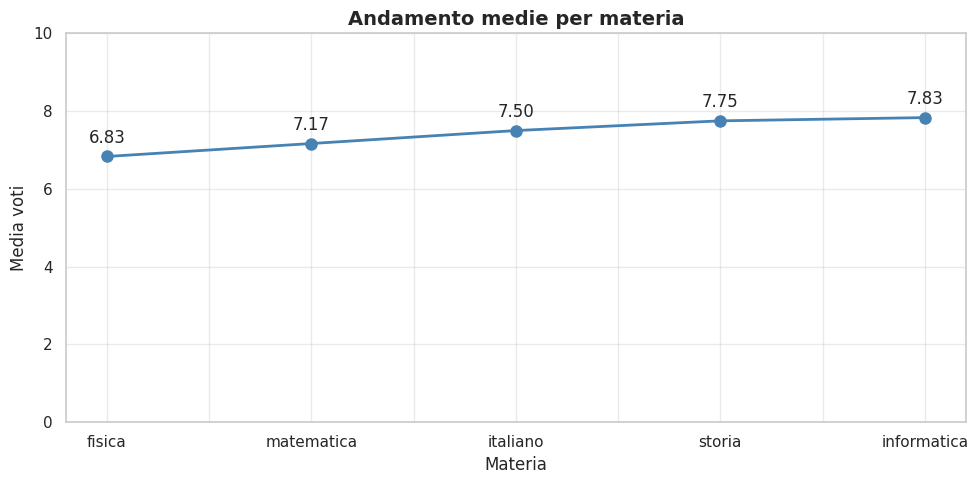

In [43]:
# Grafico a linee — utile per mostrare tendenze
# Usiamo le medie per materia come esempio

medie_materie = df[materie].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
medie_materie.plot(kind='line', marker='o', linewidth=2, markersize=8, color='steelblue', ax=ax)

ax.set_title('Andamento medie per materia', fontsize=14, fontweight='bold')
ax.set_xlabel('Materia')
ax.set_ylabel('Media voti')
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.4)

# Aggiunge i valori sui punti
for x, y in zip(range(len(medie_materie)), medie_materie):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

### Grafico a barre: kind='bar'

Il grafico a barre è ideale per **confrontare valori tra categorie discrete**. Sull'asse X ci sono le categorie, sull'asse Y i valori numerici.

```python
df.plot(kind='bar', colormap='Set2', edgecolor='white')
```

Parametri utili:
- `colormap`: schema di colori (`Set1`, `Set2`, `tab10`, `viridis`, `Paired`...)
- `stacked=True`: barre **impilate** invece di affiancate
- `ax.tick_params(axis='x', rotation=0)`: ruota le etichette sull'asse X
- `ax.legend(bbox_to_anchor=(1.01, 1))`: sposta la legenda fuori dal grafico


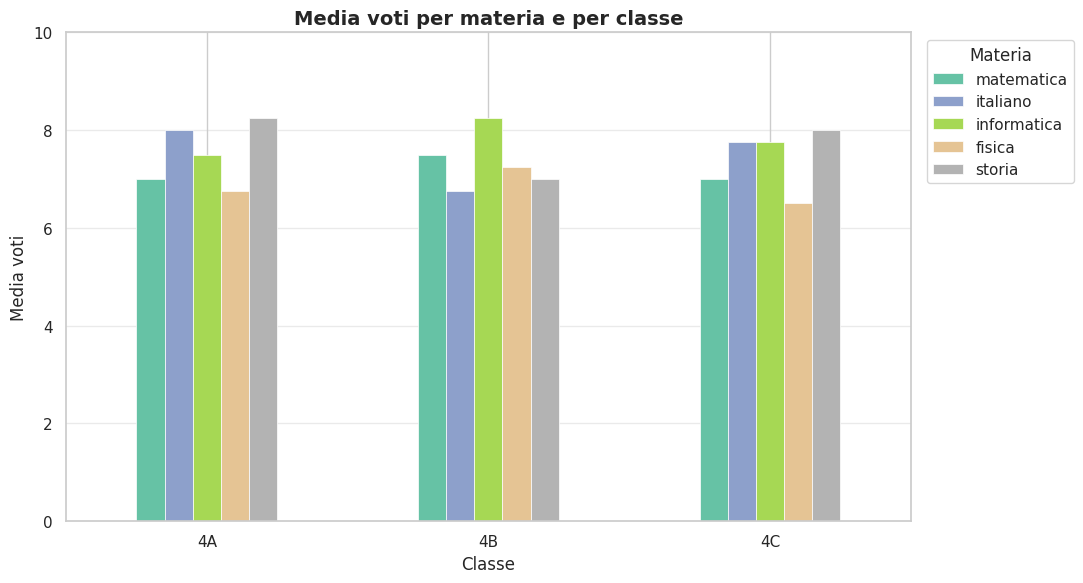

In [44]:
# Grafico a barre — confronto tra categorie

media_x_classe = df.groupby('classe')[materie].mean().round(2)

fig, ax = plt.subplots(figsize=(11, 6))
media_x_classe.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)

ax.set_title('Media voti per materia e per classe', fontsize=14, fontweight='bold')
ax.set_xlabel('Classe')
ax.set_ylabel('Media voti')
ax.set_ylim(0, 10)
ax.legend(title='Materia', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### Barre orizzontali e personalizzazioni con Matplotlib

`kind='barh'` (**h**orizontal) crea barre orizzontali — preferibile quando le etichette sull'asse categorico sono lunghe o numerose.

Personalizzazioni utili di Matplotlib:
- `ax.axvline(x=val)` / `ax.axhline(y=val)`: aggiunge una linea verticale/orizzontale di riferimento
- `color=lista_colori`: colore diverso per ogni barra (es. rosso se insufficiente)
- `ax.set_xlim(min, max)` / `ax.set_ylim(min, max)`: imposta i limiti degli assi
- `label=...` + `ax.legend()`: aggiunge la voce alla legenda


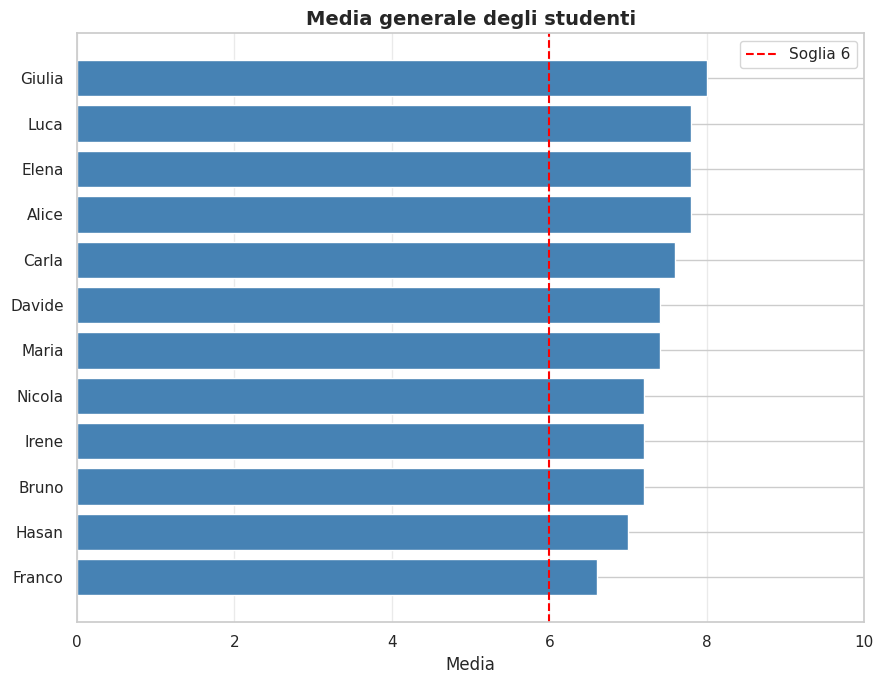

In [45]:
# Grafico a barre orizzontali — utile quando le etichette sono lunghe

df_sorted = df.sort_values('media', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['tomato' if v < 6.5 else 'steelblue' for v in df_sorted['media']]
ax.barh(df_sorted['nome'], df_sorted['media'], color=colors, edgecolor='white')

ax.axvline(x=6, color='red', linestyle='--', linewidth=1.5, label='Soglia 6')
ax.set_title('Media generale degli studenti', fontsize=14, fontweight='bold')
ax.set_xlabel('Media')
ax.set_xlim(0, 10)
ax.legend()
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

### Istogramma: kind='hist'

L'istogramma mostra la **distribuzione di frequenza** di una variabile numerica: divide il range dei valori in intervalli (**bin**) e conta quante osservazioni cadono in ciascuno.

```python
df['col'].plot(kind='hist', bins=10)
```

- **`bins`**: numero di intervalli (più bin → più dettaglio, ma rischio di rumore)
- **`density=True`**: normalizza l'asse Y come densità (area totale = 1), necessario per confrontare con una distribuzione teorica
- **`ax.axvline(valore)`**: aggiunge una linea verticale (es. per indicare la media)

> Un istogramma simmetrico a forma di campana suggerisce una distribuzione normale; un istogramma asimmetrico indica una distribuzione con coda.


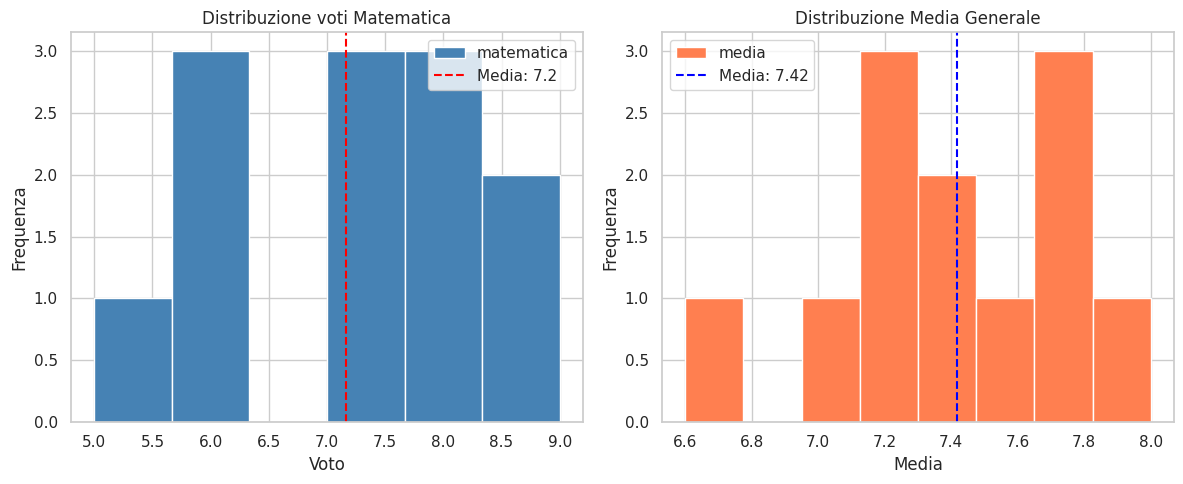

In [46]:
# Istogramma — distribuzione di una variabile numerica
# Risponde a: "quanti studenti hanno voti in ogni fascia?"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Istogramma dei voti di matematica
df['matematica'].plot(kind='hist', bins=6, color='steelblue',
                      edgecolor='white', ax=axes[0])
axes[0].set_title('Distribuzione voti Matematica')
axes[0].set_xlabel('Voto')
axes[0].set_ylabel('Frequenza')
axes[0].axvline(df['matematica'].mean(), color='red',
                linestyle='--', label=f'Media: {df["matematica"].mean():.1f}')
axes[0].legend()

# Istogramma della media generale
df['media'].plot(kind='hist', bins=8, color='coral',
                 edgecolor='white', ax=axes[1])
axes[1].set_title('Distribuzione Media Generale')
axes[1].set_xlabel('Media')
axes[1].set_ylabel('Frequenza')
axes[1].axvline(df['media'].mean(), color='blue',
                linestyle='--', label=f'Media: {df["media"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### Scatter plot: ax.scatter()

Lo scatter plot (grafico di dispersione) visualizza la **relazione tra due variabili numeriche**: ogni punto rappresenta un'osservazione (es. uno studente).

```python
ax.scatter(x, y, s=dimensione, alpha=trasparenza, color=colore)
```

- **`s`**: dimensione dei punti (in punti²)
- **`alpha`**: trasparenza (0 = invisibile, 1 = opaco) — utile per dataset sovrapposti
- **`ax.annotate(testo, (x, y))`**: aggiunge un'etichetta vicino a un punto

**`np.polyfit(x, y, grado)`** calcola i coefficienti della retta di regressione con il metodo dei minimi quadrati: restituisce `[m, b]` per la retta `y = mx + b`.


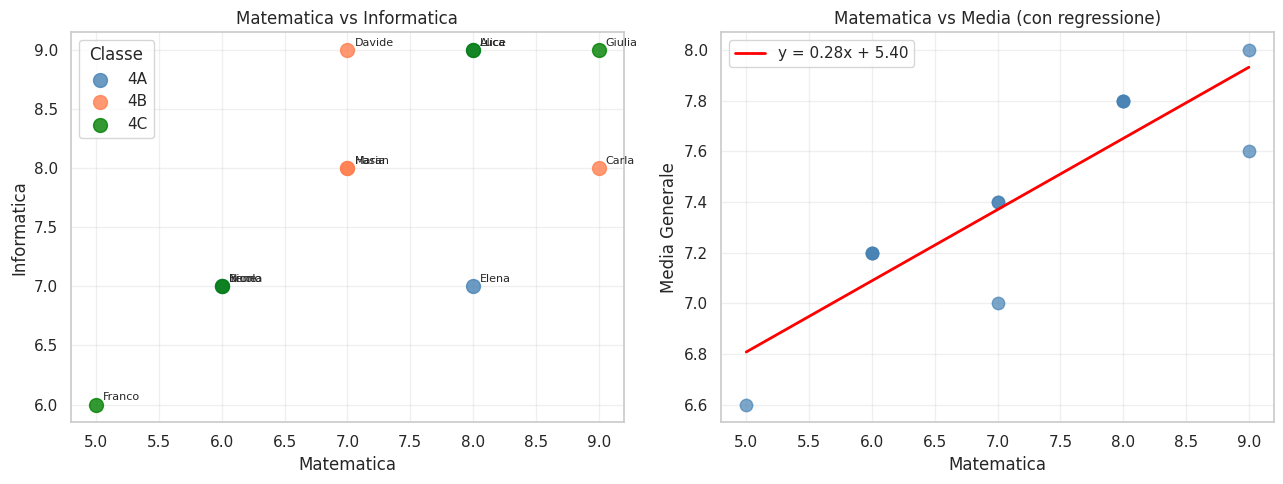

In [47]:
# Scatter plot (dispersione) — relazione tra due variabili numeriche
# Utile per visualizzare la correlazione

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matematica vs Informatica
colori_classe = {'4A': 'steelblue', '4B': 'coral', '4C': 'green'}
for classe, gruppo in df.groupby('classe'):
    axes[0].scatter(gruppo['matematica'], gruppo['informatica'],
                    label=classe, color=colori_classe[classe],
                    s=100, alpha=0.8)
    # Aggiunge il nome di ogni punto
    for _, row in gruppo.iterrows():
        axes[0].annotate(row['nome'], (row['matematica'], row['informatica']),
                         textcoords='offset points', xytext=(5, 3), fontsize=8)

axes[0].set_title('Matematica vs Informatica')
axes[0].set_xlabel('Matematica')
axes[0].set_ylabel('Informatica')
axes[0].legend(title='Classe')
axes[0].grid(alpha=0.3)

# Scatter con linea di tendenza (regressione lineare)
axes[1].scatter(df['matematica'], df['media'], color='steelblue', s=80, alpha=0.7)

# Linea di regressione con NumPy
m, b = np.polyfit(df['matematica'], df['media'], 1)
x_line = np.linspace(df['matematica'].min(), df['matematica'].max(), 100)
axes[1].plot(x_line, m * x_line + b, color='red', linewidth=2,
             label=f'y = {m:.2f}x + {b:.2f}')

axes[1].set_title('Matematica vs Media (con regressione)')
axes[1].set_xlabel('Matematica')
axes[1].set_ylabel('Media Generale')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Grafico a torta: ax.pie()

Il grafico a torta visualizza le **proporzioni** di un intero. Ogni fetta rappresenta la quota percentuale di una categoria.

```python
ax.pie(valori, labels=etichette, autopct='%1.0f%%', explode=[0.05, ...])
```

- **`autopct`**: formato della percentuale (es. `'%1.1f%%'` = un decimale, `'%1.0f%%'` = nessuno)
- **`explode`**: lista di offset per "staccare" le fette (0 = aderente, 0.05 = leggermente staccata)
- **`startangle`**: angolo di inizio del primo settore (default: 0 = ore 3)

> Il grafico a torta è difficile da leggere quando le fette sono molte o simili. Preferire il grafico a barre quando si confrontano più di 4–5 categorie.


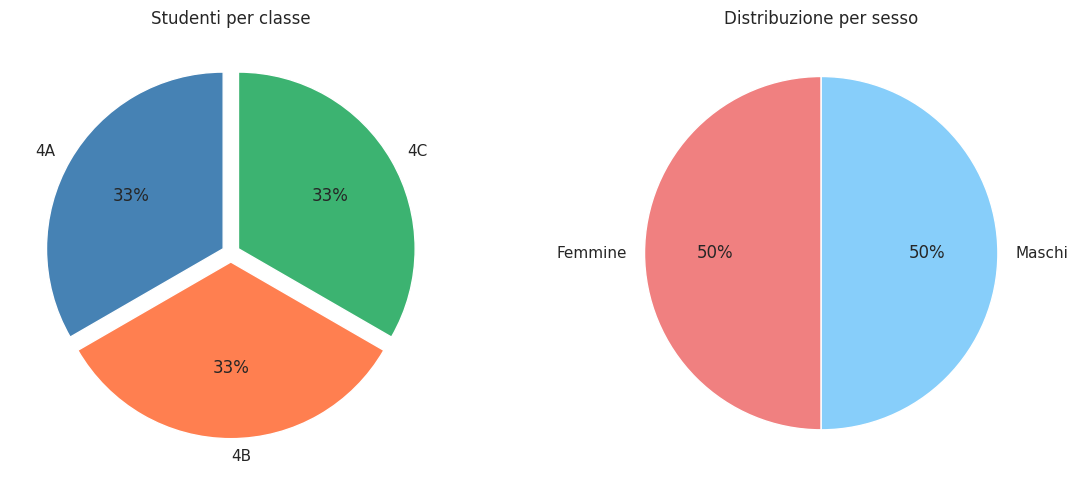

In [48]:
# Grafico a torta — proporzioni

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribuzione per classe
conteggio_classi = df['classe'].value_counts()
axes[0].pie(conteggio_classi.values,
            labels=conteggio_classi.index,
            autopct='%1.0f%%',
            startangle=90,
            colors=['steelblue', 'coral', 'mediumseagreen'],
            explode=[0.05, 0.05, 0.05])
axes[0].set_title('Studenti per classe')

# Distribuzione per sesso
conteggio_sesso = df['sesso'].value_counts()
axes[1].pie(conteggio_sesso.values,
            labels=['Femmine', 'Maschi'],
            autopct='%1.0f%%',
            startangle=90,
            colors=['lightcoral', 'lightskyblue'])
axes[1].set_title('Distribuzione per sesso')

plt.tight_layout()
plt.show()

### Box plot: kind='box' / sns.boxplot()

Il box plot (diagramma a scatola) riassume visivamente la **distribuzione statistica** di una variabile con 5 numeri:

```
|---[baffo]---[  Q1 | MEDIANA | Q3  ]---[baffo]---|  ● outlier
```

| Elemento | Significato |
|----------|-------------|
| Linea centrale | **Mediana** (Q2, 50° percentile) |
| Bordi del box | **Q1** (25°) e **Q3** (75°) |
| Baffi | Fino a **1.5 × IQR** da Q1 e Q3 |
| Punti isolati | **Outlier**: valori anomali oltre i baffi |

**Seaborn** (`sns.boxplot`) aggiunge la possibilità di raggruppare i box per colore con il parametro `hue` e offre uno stile grafico più curato.


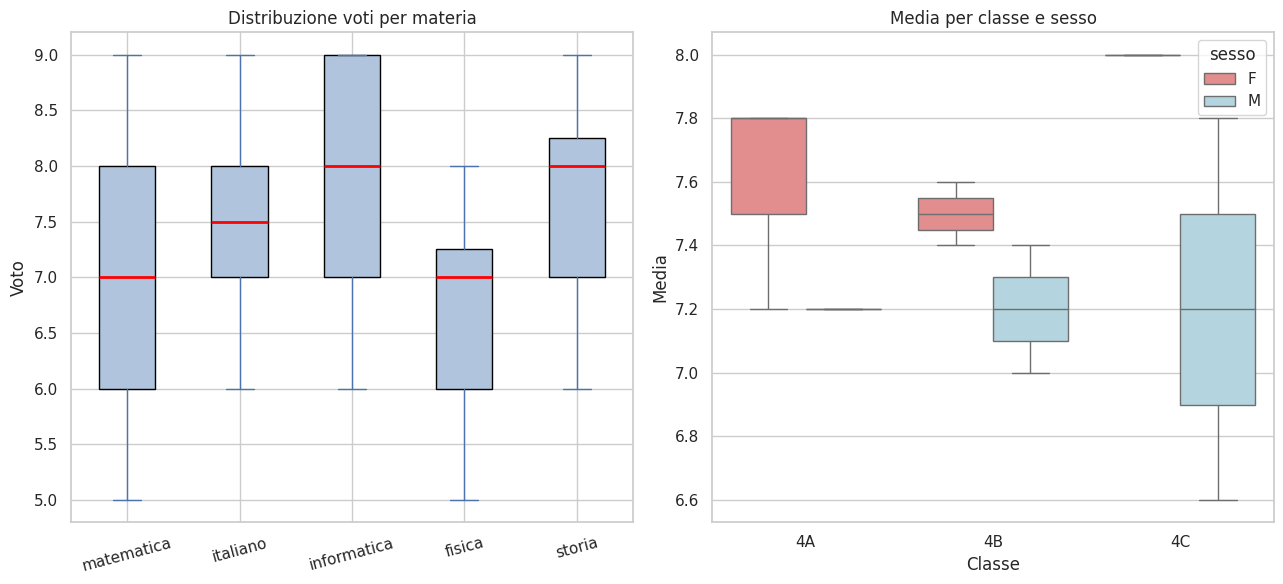

In [49]:
# Box plot — distribuzione statistica con mediana, quartili e outlier
#
# Il box mostra:
#   - linea centrale: mediana (Q2)
#   - bordi del box: Q1 (25%) e Q3 (75%)
#   - baffi: 1.5 × IQR
#   - punti isolati: outlier

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Box plot di tutte le materie
df[materie].plot(kind='box', ax=axes[0], patch_artist=True,
                 boxprops=dict(facecolor='lightsteelblue'),
                 medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Distribuzione voti per materia')
axes[0].set_ylabel('Voto')
axes[0].tick_params(axis='x', rotation=15)

# Box plot della media per classe (con Seaborn)
sns.boxplot(data=df, x='classe', y='media', hue='sesso',
            palette={'M': 'lightblue', 'F': 'lightcoral'}, ax=axes[1])
axes[1].set_title('Media per classe e sesso')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Media')

plt.tight_layout()
plt.show()

### Griglia di grafici: plt.subplots(righe, colonne)

`plt.subplots(n_righe, n_colonne)` crea una **griglia di assi** su cui disegnare grafici diversi nello stesso foglio:

```python
fig, axes = plt.subplots(2, 3, figsize=(14, 9))   # griglia 2×3
ax = axes[riga][colonna]                           # accede al singolo asse
```

- `fig.suptitle(...)`: titolo generale sopra tutti i grafici
- `axes[r][c].axis('off')`: nasconde un asse (utile se la griglia ha celle vuote)
- `plt.tight_layout()`: ottimizza automaticamente i margini tra i grafici
- `figsize=(larghezza, altezza)`: dimensione del foglio in pollici


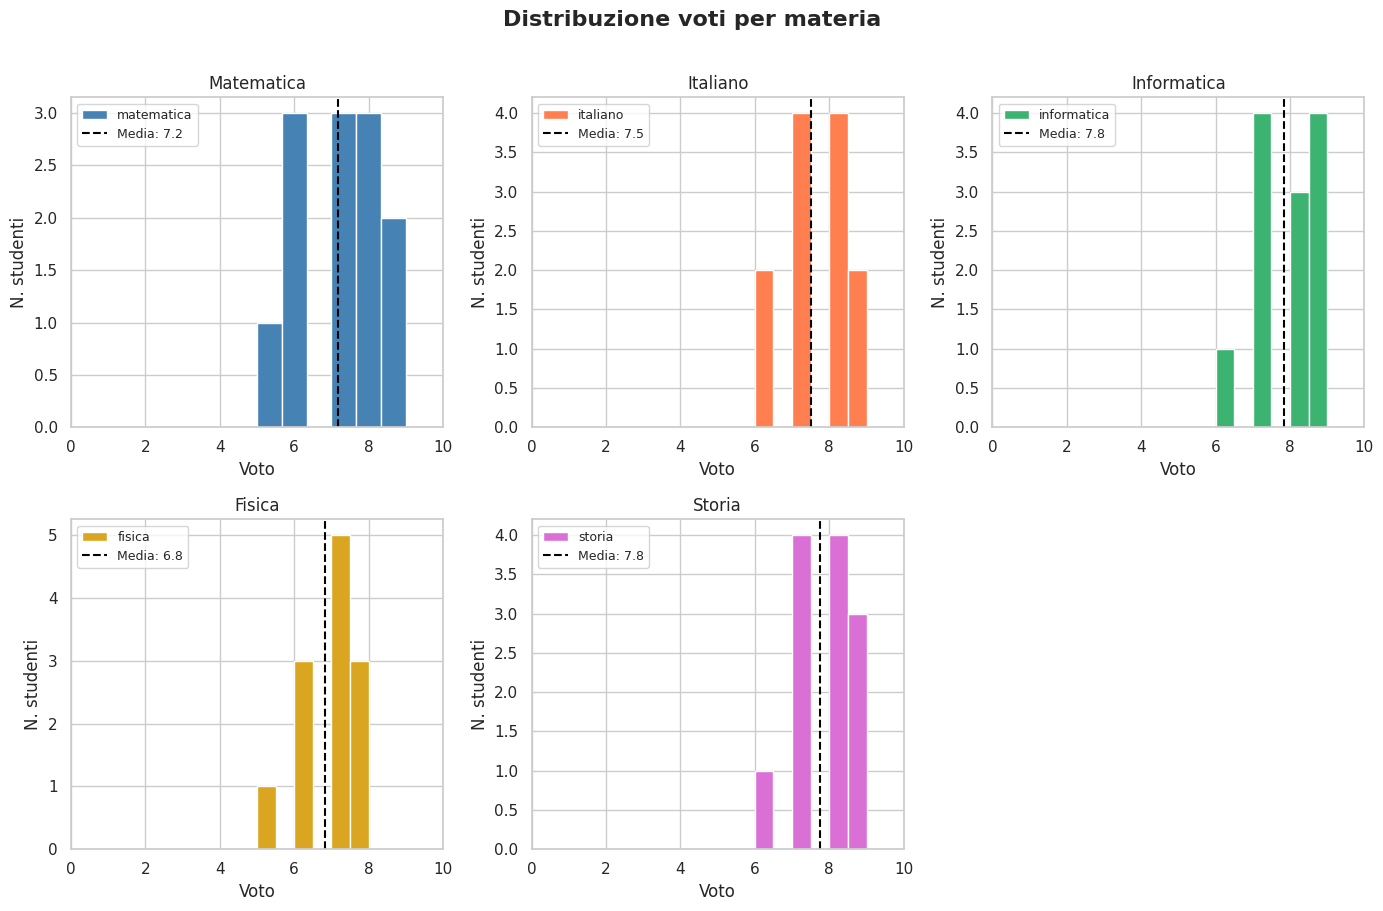

In [50]:
# Griglia di subplot: tutti i voti su un unico foglio

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Distribuzione voti per materia', fontsize=16, fontweight='bold', y=1.01)

colori = ['steelblue', 'coral', 'mediumseagreen', 'goldenrod', 'orchid']

for i, (materia, colore) in enumerate(zip(materie, colori)):
    riga = i // 3
    col  = i % 3
    ax = axes[riga][col]

    df[materia].plot(kind='hist', bins=6, color=colore, edgecolor='white', ax=ax)
    ax.axvline(df[materia].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {df[materia].mean():.1f}')
    ax.set_title(materia.capitalize())
    ax.set_xlabel('Voto')
    ax.set_ylabel('N. studenti')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 10)

# Nasconde il 6° subplot vuoto
axes[1][2].axis('off')

plt.tight_layout()
plt.show()

---
## 11. Heatmap <a id='11'></a>

Una **heatmap** (mappa di calore) rappresenta i valori di una matrice usando colori.
È particolarmente utile per visualizzare:
- La **matrice di correlazione** (quanto due variabili si muovono insieme)
- Tabelle di contingenza (crosstab)
- Qualsiasi dato bidimensionale dove il colore aiuta a identificare pattern

Il coefficiente di correlazione di Pearson va da **-1 a +1**:
- **+1**: correlazione positiva perfetta
- **0**: nessuna correlazione lineare
- **-1**: correlazione negativa perfetta

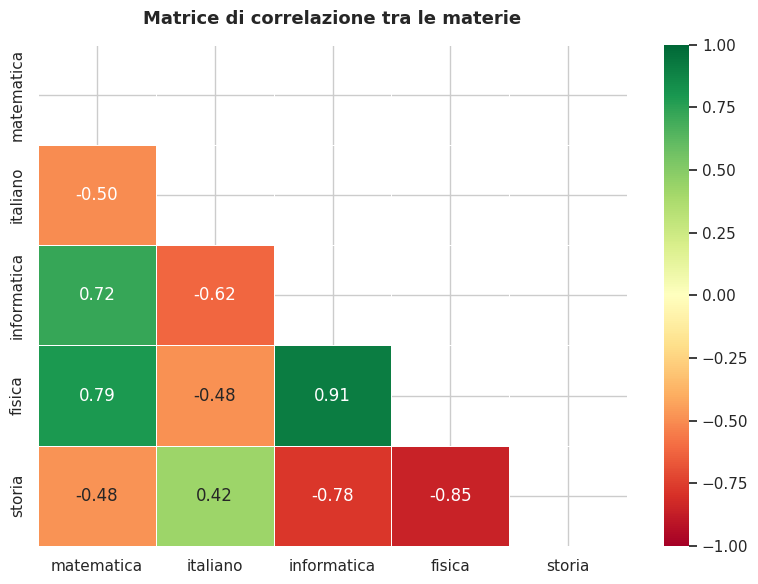


Correlazioni più forti:
informatica  fisica         0.910259
matematica   fisica         0.790724
             informatica    0.719763
italiano     storia         0.423793
matematica   storia        -0.483030
dtype: float64


In [51]:
# Heatmap della matrice di correlazione

corr_matrix = df[materie].corr()

fig, ax = plt.subplots(figsize=(8, 6))

# Maschera per nascondere la parte triangolare superiore (speculare)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,              # nasconde il triangolo superiore
    annot=True,             # scrive il valore in ogni cella
    fmt='.2f',              # formato: 2 decimali
    cmap='RdYlGn',          # palette: rosso-giallo-verde
    vmin=-1, vmax=1,        # scala fissa da -1 a +1
    linewidths=0.5,
    ax=ax
)

ax.set_title('Matrice di correlazione tra le materie', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\nCorrelazioni più forti:')
# Trova le coppie con correlazione più alta (escludendo la diagonale)
corr_unstacked = corr_matrix.where(~mask).unstack().dropna().sort_values(ascending=False)
print(corr_unstacked[corr_unstacked < 1].head(5))

### Heatmap di una tabella di contingenza

Una heatmap può visualizzare qualsiasi matrice numerica. Applicata a una **crosstab**, permette di confrontare visivamente tutte le celle: celle più scure (o più sature) indicano valori più alti.

Parametri principali di `sns.heatmap()`:

| Parametro | Descrizione |
|-----------|-------------|
| `cmap` | Tavolozza di colori (`'YlOrRd'`, `'Blues'`, `'RdYlGn'`, `'coolwarm'`...) |
| `vmin` / `vmax` | Limiti della scala colori — mantenerli fissi permette di confrontare heatmap diverse |
| `linewidths` | Spessore delle linee di separazione tra celle |
| `annot` | Se `True`, scrive il valore numerico in ogni cella |


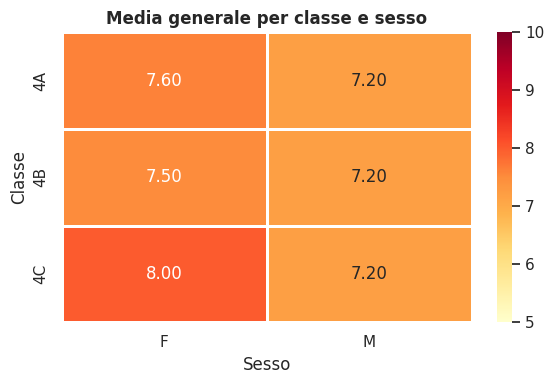

In [52]:
# Heatmap di una tabella di contingenza

tab_voti = pd.crosstab(
    df['classe'],
    df['sesso'],
    values=df[materie].mean(axis=1),
    aggfunc='mean'
).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    tab_voti,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=1,
    ax=ax,
    vmin=5, vmax=10
)
ax.set_title('Media generale per classe e sesso', fontsize=12, fontweight='bold')
ax.set_xlabel('Sesso')
ax.set_ylabel('Classe')
plt.tight_layout()
plt.show()

### Heatmap su dati grezzi

Una heatmap "grezza" mostra i valori originali senza aggregazione, permettendo di identificare visivamente pattern in dati bidimensionali (es. tutti i voti per studente e per materia).

`df.set_index('colonna')` imposta una colonna come **etichetta delle righe** (appaiono sull'asse Y della heatmap).

Parametri aggiuntivi utili:
- **`fmt='d'`**: formato intero per le annotazioni (invece di float con decimali)
- **`linecolor`**: colore delle linee di separazione
- **`cbar_kws={'label': '...'}`**: aggiunge un'etichetta alla barra dei colori


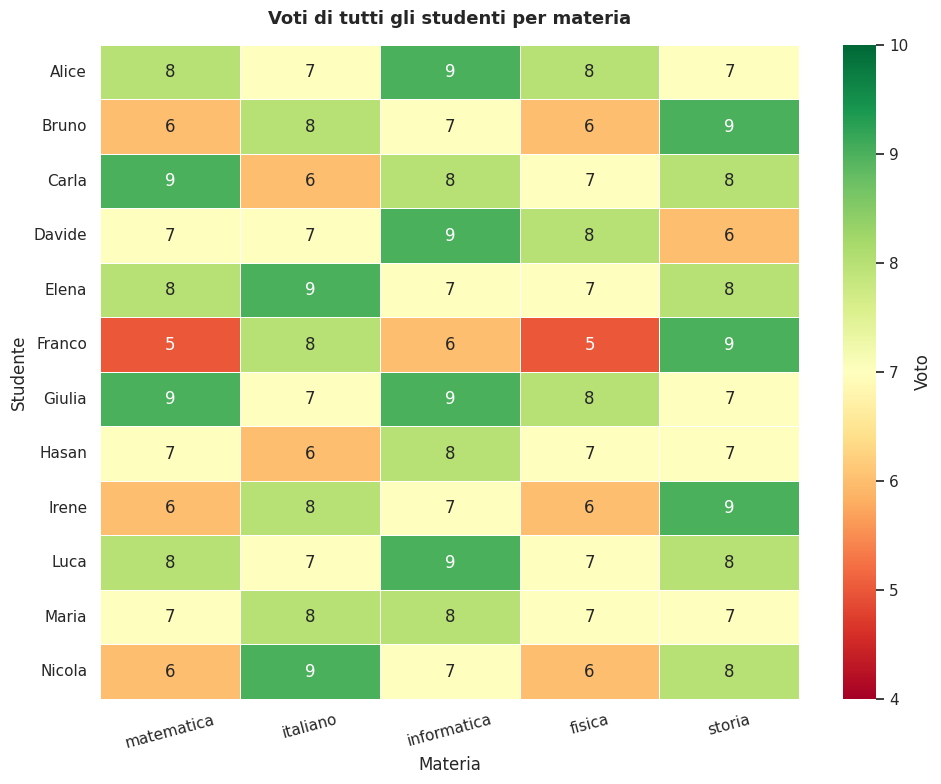

In [53]:
# Heatmap personalizzata: voti di tutti gli studenti per materia
# (una riga = uno studente, una colonna = una materia)

df_heatmap = df.set_index('nome')[materie]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_heatmap,
    annot=True,
    fmt='d',
    cmap='RdYlGn',
    vmin=4, vmax=10,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Voto'},
    ax=ax
)
ax.set_title('Voti di tutti gli studenti per materia', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Materia')
ax.set_ylabel('Studente')
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

---
## 12. Approfondimenti: NumPy e SciPy <a id='12'></a>

### NumPy
**NumPy** è la libreria di base per il calcolo numerico in Python.
Pandas è costruito sopra NumPy: ogni colonna di un DataFrame è internamente un array NumPy.

### SciPy
**SciPy** estende NumPy con funzioni scientifiche avanzate:
- Test statistici (t-test, chi-quadro, ANOVA...)
- Ottimizzazione e regressione
- Elaborazione segnali, algebra lineare, interpolazione

In [54]:
# NumPy — operazioni su array

# Estrarre valori di una colonna come array NumPy
arr_mat = df['matematica'].to_numpy()
print('Array NumPy:', arr_mat)
print('Tipo:', type(arr_mat))
print()

# Statistiche con NumPy (equivalenti a quelle di pandas)
print(f'Media:    {np.mean(arr_mat):.2f}')
print(f'Mediana:  {np.median(arr_mat):.2f}')
print(f'Varianza: {np.var(arr_mat):.3f}')     # varianza POPOLAZIONE (/ n)
print(f'Var. camp:{np.var(arr_mat, ddof=1):.3f}') # varianza CAMPIONARIA (/ n-1)
print(f'Std:      {np.std(arr_mat, ddof=1):.3f}')
print()

# Funzioni matematiche elemento per elemento
print('Radice quadrata dei voti:', np.sqrt(arr_mat).round(2))
print('Voti al quadrato:', arr_mat ** 2)

Array NumPy: [8 6 9 7 8 5 9 7 6 8 7 6]
Tipo: <class 'numpy.ndarray'>

Media:    7.17
Mediana:  7.00
Varianza: 1.472
Var. camp:1.606
Std:      1.267

Radice quadrata dei voti: [2.83 2.45 3.   2.65 2.83 2.24 3.   2.65 2.45 2.83 2.65 2.45]
Voti al quadrato: [64 36 81 49 64 25 81 49 36 64 49 36]


### NumPy — Creazione di array e operazioni matriciali

| Funzione | Descrizione |
|----------|-------------|
| `np.linspace(start, stop, n)` | `n` valori equidistanti da `start` a `stop` (inclusi) |
| `np.arange(start, stop, step)` | Valori da `start` a `stop` con passo `step` (come `range()`) |
| `np.zeros((r, c))` | Matrice di zeri di dimensione r×c |
| `np.random.randint(low, high, size)` | Interi casuali |

**Prodotto matriciale**: in NumPy si usa l'operatore **`@`** (o `np.dot()`). L'operatore `*` fa invece il prodotto **elemento per elemento** — due cose molto diverse!

```python
A @ B      # prodotto matriciale
A * B      # prodotto elemento per elemento (Hadamard product)
```


In [55]:
# NumPy — creazione di array e operazioni matriciali

# linspace: n valori equidistanti in un intervallo
x = np.linspace(0, 10, 100)

# arange: come range() ma per array
voti_possibili = np.arange(1, 11)
print('Voti da 1 a 10:', voti_possibili)

# zeros, ones, random
mat_zero = np.zeros((3, 3))
mat_rand = np.random.randint(1, 10, size=(3, 3))
print('Matrice random (3x3):')
print(mat_rand)
print()

# Prodotto matriciale
mat_a = np.array([[1, 2], [3, 4]])
mat_b = np.array([[5, 6], [7, 8]])
print('Prodotto matriciale A @ B:')
print(mat_a @ mat_b)

Voti da 1 a 10: [ 1  2  3  4  5  6  7  8  9 10]
Matrice random (3x3):
[[4 3 1]
 [7 9 8]
 [2 1 9]]

Prodotto matriciale A @ B:
[[19 22]
 [43 50]]


### SciPy Stats — Test t di Student

Il **test t di Student** (`stats.ttest_ind`) verifica se le medie di due gruppi indipendenti sono statisticamente diverse, tenendo conto della variabilità interna dei dati.

Restituisce due valori:
- **t-statistica**: quanto sono distanti le medie rispetto alla variabilità dei dati
- **p-value**: probabilità di osservare questa differenza per puro caso, assumendo che i due gruppi siano identici (ipotesi nulla H₀)

> **Regola pratica:** se `p-value < 0.05` si **rifiuta l'ipotesi nulla** → la differenza è statisticamente significativa al livello del 5%. Questo NON significa che la differenza sia grande o importante, solo che è reale.


In [56]:
# SciPy Stats — test statistici

# Test t di Student: i maschi hanno una media di matematica diversa dalle femmine?
mat_maschi = df[df['sesso'] == 'M']['matematica']
mat_femmine = df[df['sesso'] == 'F']['matematica']

t_stat, p_value = stats.ttest_ind(mat_maschi, mat_femmine)

print('=== Test t di Student ===')
print(f'Media maschi:   {mat_maschi.mean():.2f}')
print(f'Media femmine:  {mat_femmine.mean():.2f}')
print(f'Statistica t:   {t_stat:.4f}')
print(f'p-value:        {p_value:.4f}')
print()
if p_value < 0.05:
    print('Risultato: differenza SIGNIFICATIVA (p < 0.05)')
else:
    print('Risultato: differenza NON significativa (p >= 0.05)')

=== Test t di Student ===
Media maschi:   6.50
Media femmine:  7.83
Statistica t:   -2.0795
p-value:        0.0643

Risultato: differenza NON significativa (p >= 0.05)


### SciPy — Test di normalità e regressione lineare

**Test di Shapiro-Wilk** (`stats.shapiro`): verifica se un campione segue una **distribuzione normale**. Se `p > 0.05` non c'è evidenza per rifiutare la normalità (il campione è compatibile con una normale).

**`stats.linregress(x, y)`** calcola la **retta di regressione** con il metodo dei minimi quadrati e restituisce:

| Valore | Significato |
|--------|-------------|
| `slope`, `intercept` | Coefficienti della retta `y = mx + b` |
| `r_value` | Coefficiente di correlazione di Pearson (r) |
| `r_value**2` | **R²** — proporzione di varianza di y spiegata da x |
| `p_value` | Significatività statistica della correlazione |


In [57]:
# SciPy — distribuzione normale e normalità

# Test di Shapiro-Wilk: i voti di matematica seguono una distribuzione normale?
stat, p = stats.shapiro(df['matematica'])
print(f'Test di Shapiro-Wilk — matematica:')
print(f'  Statistica W: {stat:.4f}')
print(f'  p-value: {p:.4f}')
print(f'  Distribuzione normale: {"Si" if p > 0.05 else "No"} (p {">=" if p >= 0.05 else "<"} 0.05)')
print()

# Regressione lineare con scipy
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df['matematica'], df['media']
)
print('=== Regressione lineare: matematica → media ===')
print(f'  y = {slope:.3f}x + {intercept:.3f}')
print(f'  r² = {r_value**2:.4f}  (varianza spiegata: {r_value**2*100:.1f}%)')
print(f'  p-value: {p_value:.4f}')

Test di Shapiro-Wilk — matematica:
  Statistica W: 0.9361
  p-value: 0.4493
  Distribuzione normale: Si (p >= 0.05)

=== Regressione lineare: matematica → media ===
  y = 0.281x + 5.402
  r² = 0.7772  (varianza spiegata: 77.7%)
  p-value: 0.0001


### Sovrapporre la curva normale all'istogramma

Per confrontare la distribuzione dei dati con quella normale teorica si sovrappongono due grafici:

1. **Istogramma** con `density=True` (l'asse Y diventa densità, area totale = 1)
2. **Curva PDF** calcolata con `stats.norm.pdf(x, loc=media, scale=std)`

```python
stats.norm.pdf(x, loc=media, scale=std)   # densità della normale in ogni punto x
```

`np.linspace(min, max, 200)` genera 200 punti x equidistanti su cui valutare la PDF — più punti = curva più liscia.


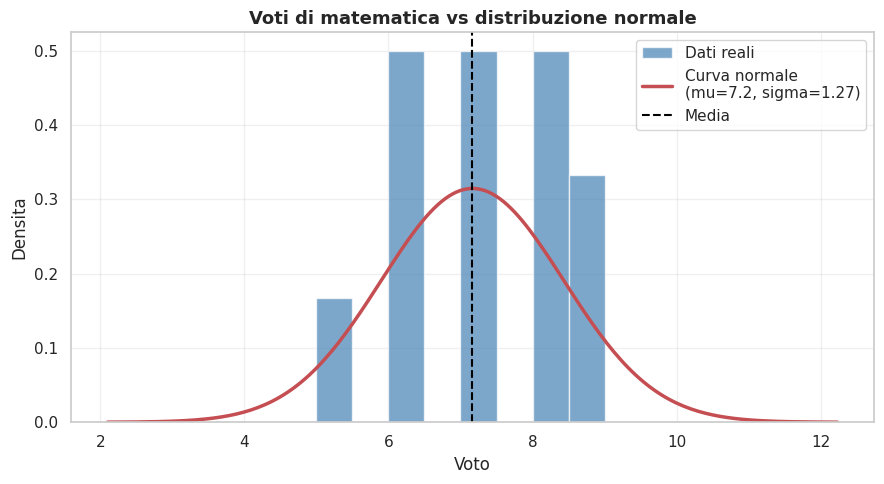

In [58]:
# Visualizzazione della distribuzione normale sovrapposta all'istogramma

fig, ax = plt.subplots(figsize=(9, 5))

# Dati
media_val = df['matematica'].mean()
std_val   = df['matematica'].std()

# Istogramma normalizzato (density=True)
df['matematica'].plot(kind='hist', bins=8, density=True,
                      color='steelblue', edgecolor='white',
                      alpha=0.7, ax=ax, label='Dati reali')

# Curva normale teorica
x_norm = np.linspace(media_val - 4*std_val, media_val + 4*std_val, 200)
y_norm = stats.norm.pdf(x_norm, loc=media_val, scale=std_val)
ax.plot(x_norm, y_norm, 'r-', linewidth=2.5,
        label=f'Curva normale\n(mu={media_val:.1f}, sigma={std_val:.2f})')

ax.axvline(media_val, color='black', linestyle='--', linewidth=1.5, label='Media')
ax.set_title('Voti di matematica vs distribuzione normale', fontsize=13, fontweight='bold')
ax.set_xlabel('Voto')
ax.set_ylabel('Densita')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Tabella pivot: pd.pivot_table()

`pd.pivot_table()` crea **tabelle di riepilogo multi-dimensionali** simili alle tabelle pivot di Excel — è la versione più potente di `groupby`:

```python
pd.pivot_table(df,
    values=['col1', 'col2'],   # colonne da aggregare
    index='righe',             # variabile sulle righe
    columns='colonne',         # variabile sulle colonne
    aggfunc='mean'             # funzione di aggregazione
)
```

Il risultato è un DataFrame con un **MultiIndex** sulle colonne, che mostra il valore aggregato per ogni combinazione di riga e colonna.


In [59]:
# Approfondimento: pivot_table — tabella riassuntiva avanzata
# Simile a una tabella pivot di Excel

pivot = pd.pivot_table(
    df,
    values=['matematica', 'informatica', 'media'],
    index='classe',
    columns='sesso',
    aggfunc='mean'
).round(2)

print('Pivot table — medie per classe, sesso e materia:')
pivot

Pivot table — medie per classe, sesso e materia:


informatica       matematica       media     
sesso            F     M          F     M     F    M
classe                                              
4A            7.67  7.00       7.33  6.00   7.6  7.2
4B            8.00  8.50       8.00  7.00   7.5  7.2
4C            9.00  7.33       9.00  6.33   8.0  7.2

### Seaborn: pair plot

**`sns.pairplot(df)`** crea automaticamente una **griglia di scatter plot** per tutte le coppie di variabili numeriche:

- **Diagonale**: distribuzione di ogni singola variabile (`diag_kind='kde'` = curva di densità, `'hist'` = istogramma)
- **Fuori diagonale**: scatter tra ogni coppia di variabili

Con `hue='colonna'` i punti vengono colorati per categoria, rendendo visibili eventuali cluster o separazioni tra i gruppi.

È uno degli strumenti più rapidi per avere una **panoramica completa delle relazioni** tra tutte le variabili in pochi secondi.


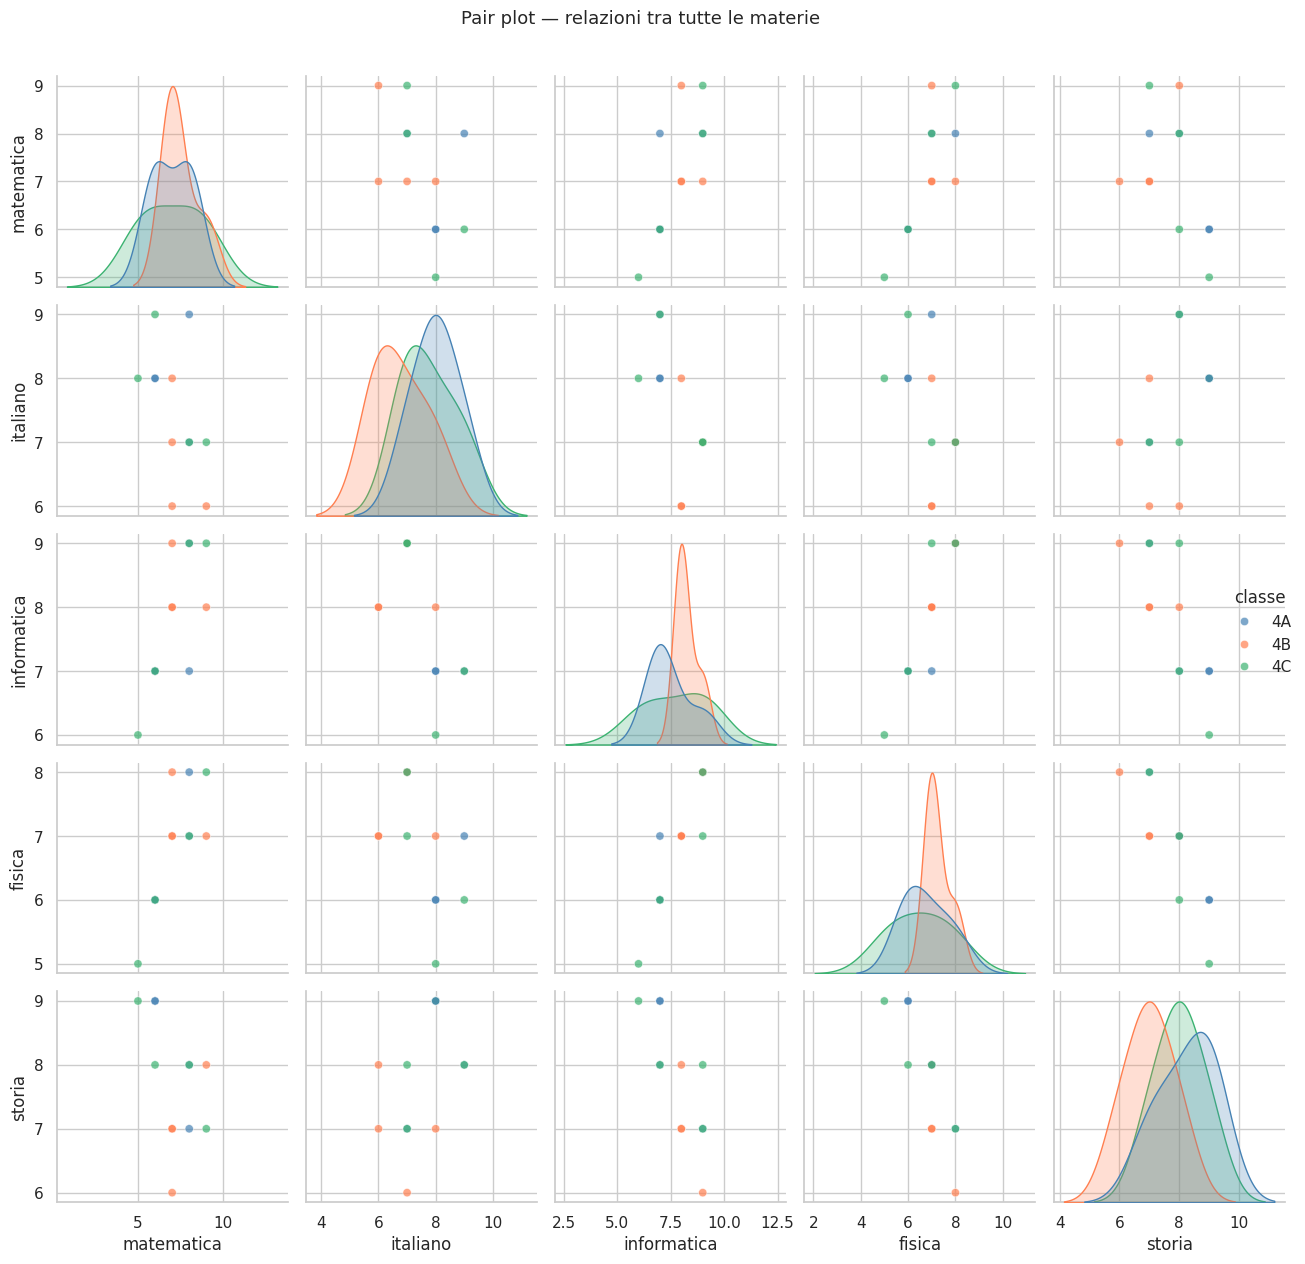

In [60]:
# Approfondimento Seaborn: pair plot
# Mostra la relazione tra tutte le coppie di variabili numeriche

df_plot = df[['matematica', 'italiano', 'informatica', 'fisica', 'storia', 'classe']].copy()

g = sns.pairplot(
    df_plot,
    hue='classe',
    palette={'4A': 'steelblue', '4B': 'coral', '4C': 'mediumseagreen'},
    diag_kind='kde',       # sulla diagonale: densità
    plot_kws={'alpha': 0.7}
)
g.figure.suptitle('Pair plot — relazioni tra tutte le materie', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Tidy data (formato lungo) e .melt()

Molte funzioni di Seaborn richiedono i dati in formato **tidy** (o _long format_): una variabile per colonna, una osservazione per riga.

`df.melt()` trasforma un DataFrame **wide** (ogni materia = una colonna) in formato **long** (ogni riga = una materia di uno studente):

```python
df.melt(
    id_vars=['nome', 'classe'],          # colonne da mantenere invariate
    value_vars=['mat', 'ita', 'info'],   # colonne da "sciogliere"
    var_name='materia',                  # nome della nuova colonna categoria
    value_name='voto'                    # nome della nuova colonna numerica
)
```

Il risultato ha molte più righe ma è nella forma richiesta da Seaborn per grafici raggruppati per categoria.


In [61]:
# Violin plot — alternativa avanzata al box plot
# Mostra la distribuzione completa dei dati

# Convertiamo il DataFrame in formato 'lungo' (tidy data) per Seaborn
df_lungo = df[['nome', 'classe'] + materie].melt(
    id_vars=['nome', 'classe'],
    value_vars=materie,
    var_name='materia',
    value_name='voto'
)

print('Formato tidy (long format):')
print(df_lungo.head(10))

Formato tidy (long format):
     nome classe     materia  voto
0   Alice     4A  matematica     8
1   Bruno     4A  matematica     6
2   Carla     4B  matematica     9
3  Davide     4B  matematica     7
4   Elena     4A  matematica     8
5  Franco     4C  matematica     5
6  Giulia     4C  matematica     9
7   Hasan     4B  matematica     7
8   Irene     4A  matematica     6
9    Luca     4C  matematica     8


### Violin plot: sns.violinplot()

Il **violin plot** combina un box plot con la stima della densità (KDE), mostrando la **forma completa della distribuzione**. Dove il violino è più largo ci sono più dati; dove è più stretto i dati sono rari.

```python
sns.violinplot(data=df, x='categoria', y='valore', hue='gruppo', inner='box')
```

| Parametro `inner` | Descrizione |
|-------------------|-------------|
| `'box'` | Mini box plot all'interno del violino |
| `'stick'` | Trattini per ogni singolo valore |
| `None` | Solo la forma del violino |

È preferibile al box plot quando si vuole verificare se la distribuzione è bimodale (due picchi) o ha forme particolari non catturate dai soli quartili.


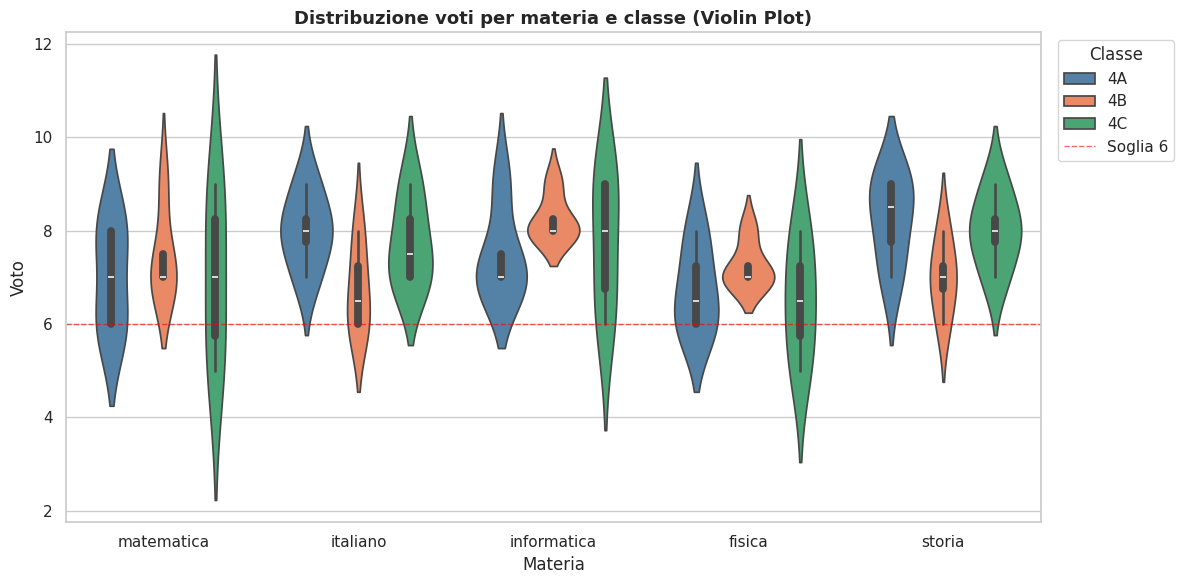

In [62]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(
    data=df_lungo,
    x='materia',
    y='voto',
    hue='classe',
    palette={'4A': 'steelblue', '4B': 'coral', '4C': 'mediumseagreen'},
    inner='box',    # box plot all'interno del violino
    ax=ax
)

ax.set_title('Distribuzione voti per materia e classe (Violin Plot)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Materia')
ax.set_ylabel('Voto')
ax.axhline(6, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Soglia 6')
ax.legend(title='Classe', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

---
## Riepilogo — Comandi Essenziali

### Creare e caricare dati
```python
pd.DataFrame(dizionario)          # Da dizionario
pd.read_csv('file.csv')           # Da file CSV
df.to_csv('output.csv', index=False) # Salva CSV
```

### Esplorare il DataFrame
```python
df.head(n)       # Prime n righe
df.tail(n)       # Ultime n righe
df.shape         # (righe, colonne)
df.dtypes        # Tipi di dati
df.info()        # Riepilogo
df.describe()    # Statistiche base
df.isnull().sum()# Valori mancanti
```

### Selezionare dati
```python
df['col']               # Singola colonna (Series)
df[['c1','c2']]         # Più colonne (DataFrame)
df.iloc[0]              # Riga per posizione
df.loc[0, 'col']        # Cella per etichetta
df[df['col'] > 5]       # Filtraggio
df['col'].isin([1,2])   # Filtra per lista
```

### Statistiche
```python
df['col'].mean()    # Media
df['col'].median()  # Mediana
df['col'].mode()    # Moda
df['col'].var()     # Varianza
df['col'].std()     # Deviazione standard
df['col'].round(2)  # Arrotondamento
```

### Trasformare dati
```python
df.groupby('col').mean()          # Raggruppa e aggrega
pd.merge(df1, df2, on='col')      # Unisci DataFrame
pd.concat([df1, df2])             # Concatena DataFrame
pd.crosstab(df['a'], df['b'])     # Tabella di contingenza
df.pivot_table(...)               # Tabella pivot
```

### Grafici
```python
df['col'].plot(kind='hist')       # Istogramma
df.plot(kind='bar')               # Barre
df.plot(kind='scatter', x=, y=)  # Dispersione
df.plot(kind='box')               # Box plot
sns.heatmap(df.corr(), annot=True)# Heatmap correlazione
```

---
*Guida realizzata per studenti di quarta — Istituto Tecnico Informatica*